In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import seaborn as sns
import pandas as pd

In [2]:
def perf_metrics(data, label):
    data_len = len(data)
    # print('Number of iterations:', data_len)
    mean = np.mean(data[label])
    var = np.var(data[label], ddof=1)
    var_mean = var/data_len

    se_mean = np.sqrt(var_mean)
    error_bound = 1.96*se_mean
    CI_low = mean - error_bound
    CI_high = mean + error_bound

    print('Error type:', label)
    print('Mean:', mean)
    print('Variance:', var)
    print('Variance of estimate:', var_mean)
    print('Standard error:', se_mean)
    print('95% Confidence Interval:  [', CI_low, ', ', CI_high, ']')
    print('-----------------------------')


## Simulated Data:

In [3]:
path_to_data = 'https://raw.githubusercontent.com/AndreiAf02/Resolving_Data_Imbalance/main/Transfer_Learning/Simulation/'

In [4]:
data_orig = pd.read_csv(path_to_data+ "Sim_Imbalanced_Fine_Tuning.csv", sep=",", header=0)
data_SRS = pd.read_csv(path_to_data+ "Sim_SRS_Fine_Tuning_Extension.csv", sep=",", header=0)
data_SRSwR = pd.read_csv(path_to_data+ "Sim_SRSwR_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sy = pd.read_csv(path_to_data+ "Sim_Sy_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sym = pd.read_csv(path_to_data+ "Sim_Sy_multi_Fine_Tuning_Extension.csv", sep=",", header=0)
data_SRS_ROS = pd.read_csv(path_to_data+ "Sim_SRS_ROS_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sy_ROS = pd.read_csv(path_to_data+ "Sim_Sy_ROS_Fine_Tuning_Extension.csv", sep=",", header=0)

data_Sy_ROS

,Unnamed: 0,FPR,FNR
0,0,0.095329,0.557093
1,1,0.081983,0.570934
2,2,0.063870,0.626298
3,3,0.099142,0.553633
4,4,0.095329,0.557093
...,...,...,...
195,95,0.080076,0.574394
196,96,0.122021,0.508651
197,97,0.056244,0.626298
198,98,0.115348,0.522491


Original (imbalanced) data performance:

Error type: FPR
Mean: 0.025757864632983744
Variance: 0.00011222685680451531
Variance of estimate: 1.1222685680451532e-06
Standard error: 0.0010593717798984231
95% Confidence Interval:  [ 0.023681495944382833 ,  0.027834233321584655 ]
-----------------------------
Error type: FNR
Mean: 0.7319031141868512
Variance: 0.0032930640198273495
Variance of estimate: 3.2930640198273495e-05
Standard error: 0.005738522475191109
95% Confidence Interval:  [ 0.7206556101354766 ,  0.7431506182382257 ]
-----------------------------


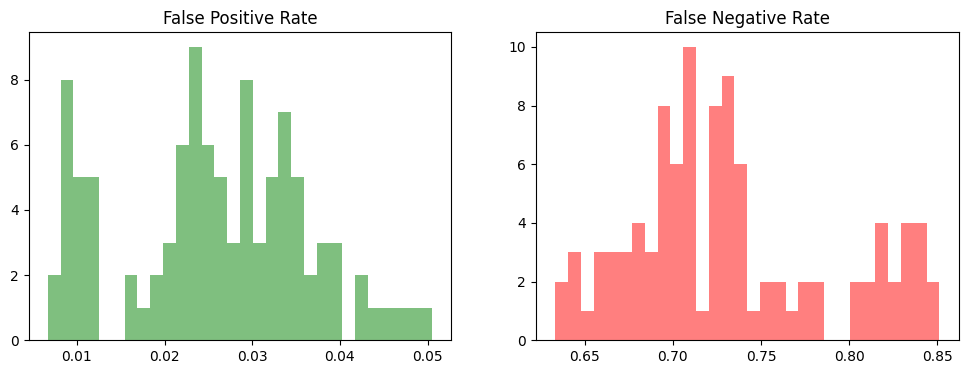

In [5]:
data = data_orig

orig_FPR = data['FPR']
orig_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

**Random Undersampling:**

SRS Random Undersampling performance:

Error type: FPR
Mean: 0.11865109626955192
Variance: 0.0008052603753032327
Variance of estimate: 4.026301876516164e-06
Standard error: 0.00200656469532287
95% Confidence Interval:  [ 0.1147182294667191 ,  0.12258396307238474 ]
-----------------------------
Error type: FNR
Mean: 0.5511764705738582
Variance: 0.004217227224836241
Variance of estimate: 2.1086136124181206e-05
Standard error: 0.0045919642990969785
95% Confidence Interval:  [ 0.5421762205476282 ,  0.5601767206000883 ]
-----------------------------


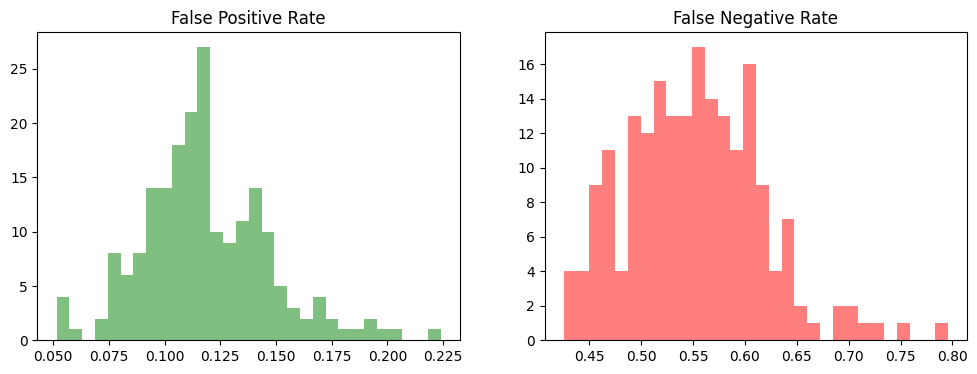

In [6]:
data = data_SRS

SRS_FPR = data['FPR']
SRS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

SRSwR undersampling performance:

Error type: FPR
Mean: 0.10657769301755955
Variance: 0.0009690574254542063
Variance of estimate: 4.8452871272710315e-06
Standard error: 0.0022012012918565696
95% Confidence Interval:  [ 0.10226333848552067 ,  0.11089204754959843 ]
-----------------------------
Error type: FNR
Mean: 0.5833044982723875
Variance: 0.007645107343400977
Variance of estimate: 3.8225536717004886e-05
Standard error: 0.006182680382892592
95% Confidence Interval:  [ 0.571186444721918 ,  0.595422551822857 ]
-----------------------------


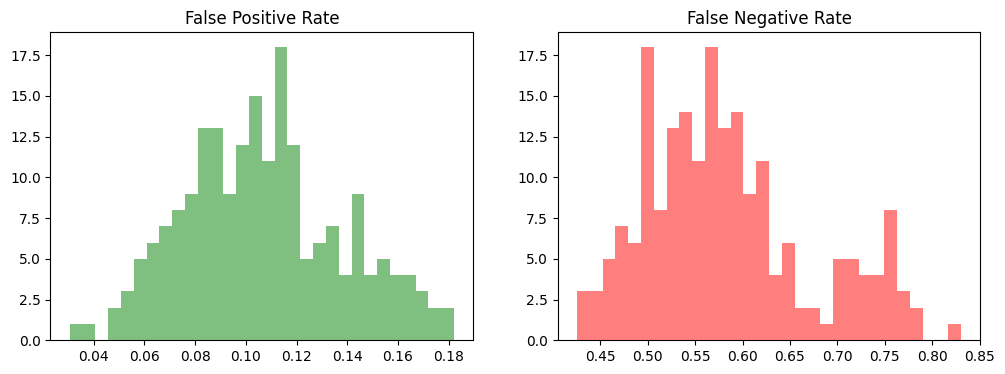

In [7]:
data = data_SRSwR

SRSwR_FPR = data['FPR']
SRSwR_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Undersampling performance:

Error type: FPR
Mean: 0.10977121066955668
Variance: 0.0008338554556674335
Variance of estimate: 4.169277278337167e-06
Standard error: 0.0020418808188376637
95% Confidence Interval:  [ 0.10576912426463486 ,  0.1137732970744785 ]
-----------------------------
Error type: FNR
Mean: 0.5718166089819723
Variance: 0.006919933596259539
Variance of estimate: 3.4599667981297695e-05
Standard error: 0.00588214824543701
95% Confidence Interval:  [ 0.5602875984209157 ,  0.5833456195430289 ]
-----------------------------


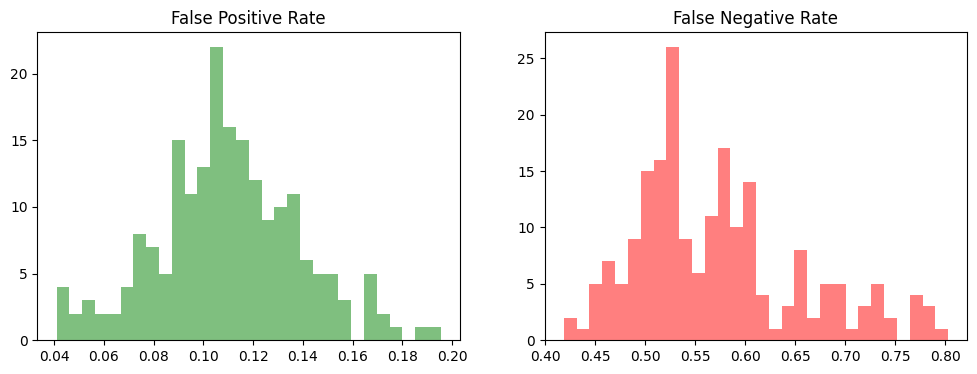

In [8]:
data = data_Sy

Sy_FPR = data['FPR']
Sy_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Multiple Systematic undersampling performance:

Error type: FPR
Mean: 0.11085319348559577
Variance: 0.0012858389532565127
Variance of estimate: 6.4291947662825635e-06
Standard error: 0.002535585685060271
95% Confidence Interval:  [ 0.10588344554287764 ,  0.11582294142831391 ]
-----------------------------
Error type: FNR
Mean: 0.581418685116263
Variance: 0.0057356152537094834
Variance of estimate: 2.867807626854742e-05
Standard error: 0.005355191524917425
95% Confidence Interval:  [ 0.5709225097274249 ,  0.5919148605051012 ]
-----------------------------


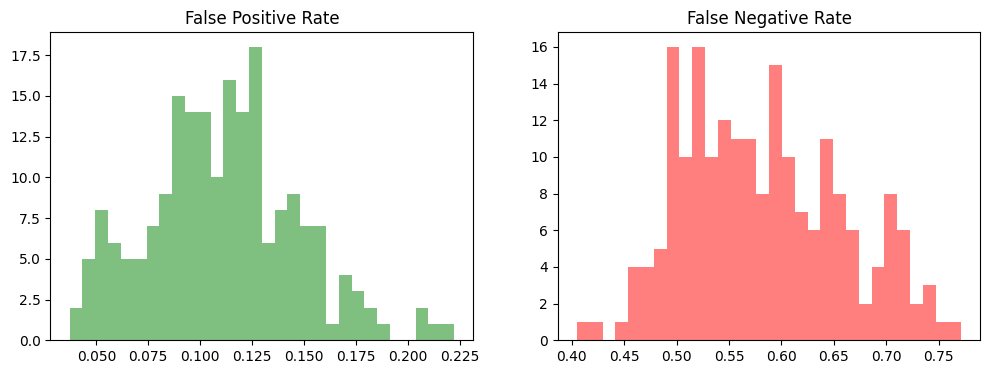

In [9]:
data = data_Sym

Sym_FPR = data['FPR']
Sym_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

**Random Oversampling:**

SRS Oversampling performance:

Error type: FPR
Mean: 0.09519542419371305
Variance: 0.0006395296771909691
Variance of estimate: 3.1976483859548456e-06
Standard error: 0.0017881969650893734
95% Confidence Interval:  [ 0.09169055814213788 ,  0.09870029024528822 ]
-----------------------------
Error type: FNR
Mean: 0.5407439446322491
Variance: 0.002734658132192362
Variance of estimate: 1.367329066096181e-05
Standard error: 0.0036977412917836494
95% Confidence Interval:  [ 0.5334963717003531 ,  0.547991517564145 ]
-----------------------------


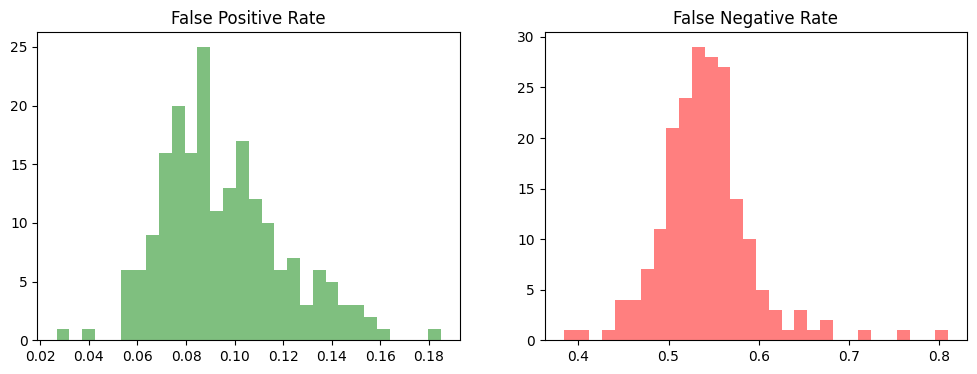

In [10]:
data = data_SRS_ROS

SRS_ROS_FPR = data['FPR']
SRS_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Resampling performance:

Error type: FPR
Mean: 0.09166348902811725
Variance: 0.0008183503498010383
Variance of estimate: 4.091751749005191e-06
Standard error: 0.002022807887320294
95% Confidence Interval:  [ 0.08769878556896947 ,  0.09562819248726502 ]
-----------------------------
Error type: FNR
Mean: 0.5647231833836505
Variance: 0.0059277117990532355
Variance of estimate: 2.9638558995266176e-05
Standard error: 0.0054441306923388765
95% Confidence Interval:  [ 0.5540526872266662 ,  0.5753936795406347 ]
-----------------------------


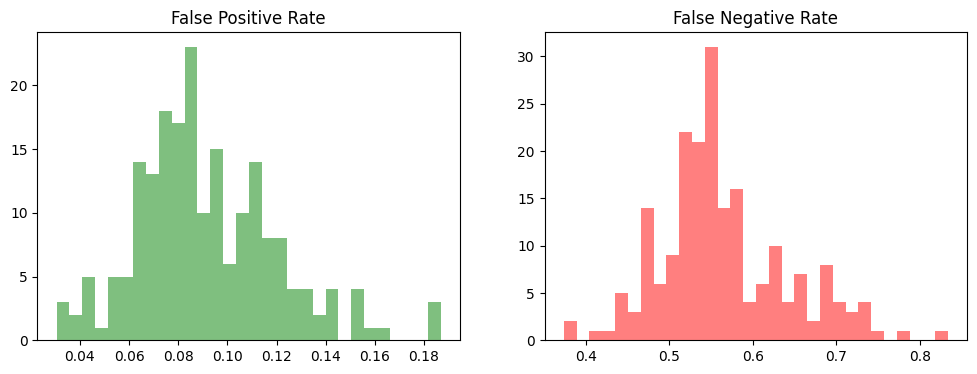

In [11]:
data = data_Sy_ROS

Sy_ROS_FPR = data['FPR']
Sy_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

In [12]:
FPR = pd.DataFrame()

DF = FPR


DF['SRS_RUS'] = SRS_FPR
DF['SRSwR_RUS'] = SRSwR_FPR
DF['Sy_RUS'] = Sy_FPR
DF['Sy_m_RUS'] = Sym_FPR
DF['SRS_ROS'] = SRS_ROS_FPR
DF['Sy_ROS'] = Sy_ROS_FPR
DF['Orig'] = orig_FPR
FPR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.141087,0.118208,0.113441,0.107722,0.101049,0.095329,0.035272
1,0.144900,0.115348,0.119161,0.122021,0.088656,0.081983,0.029552
2,0.148713,0.169685,0.090562,0.102955,0.055291,0.063870,0.023832
3,0.114395,0.108675,0.137274,0.087703,0.111535,0.099142,0.028599
4,0.125834,0.122021,0.091516,0.091516,0.133460,0.095329,0.023832
...,...,...,...,...,...,...,...
195,0.139180,0.086749,0.111535,0.125834,0.158246,0.080076,NaN
196,0.124881,0.146806,0.087703,0.136320,0.089609,0.122021,NaN
197,0.131554,0.069590,0.099142,0.147760,0.142040,0.056244,NaN
198,0.103908,0.119161,0.110582,0.073403,0.130601,0.115348,NaN


<Axes: title={'center': 'FPR'}>

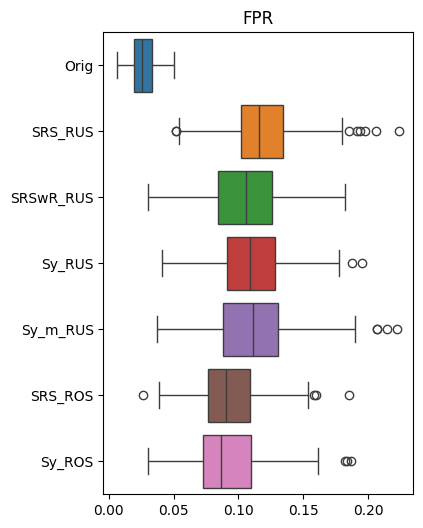

In [13]:
dataset = FPR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FPR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

In [14]:
FNR = pd.DataFrame()

DF = FNR


DF['SRS_RUS'] = SRS_FNR
DF['SRSwR_RUS'] = SRSwR_FNR
DF['Sy_RUS'] = Sy_FNR
DF['Sy_m_RUS'] = Sym_FNR
DF['SRS_ROS'] = SRS_ROS_FNR
DF['Sy_ROS'] = Sy_ROS_FNR
DF['Orig'] = orig_FNR
FNR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.522491,0.591696,0.512111,0.508651,0.519031,0.557093,0.681661
1,0.519031,0.588235,0.501730,0.494810,0.536332,0.570934,0.705882
2,0.515571,0.498270,0.595156,0.529412,0.602076,0.626298,0.733564
3,0.591696,0.608997,0.480969,0.546713,0.498270,0.553633,0.709343
4,0.564014,0.577855,0.598616,0.543253,0.480969,0.557093,0.737024
...,...,...,...,...,...,...,...
195,0.456747,0.598616,0.543253,0.608997,0.529412,0.574394,NaN
196,0.470588,0.463668,0.591696,0.595156,0.653979,0.508651,NaN
197,0.463668,0.622837,0.570934,0.577855,0.581315,0.626298,NaN
198,0.501730,0.522491,0.532872,0.712803,0.567474,0.522491,NaN


<Axes: title={'center': 'FNR'}>

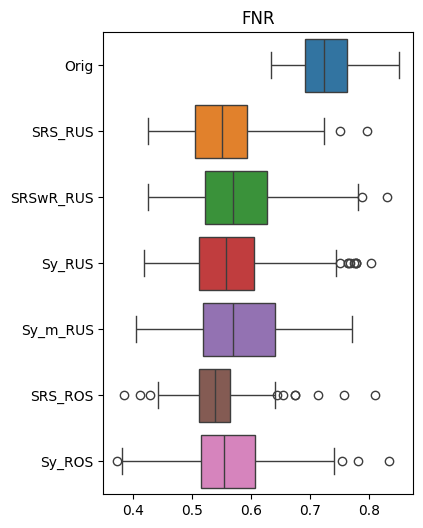

In [15]:
dataset = FNR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FNR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

## "CDC Diabetes Health Indicators" Data:


In [16]:
path_to_data = 'https://raw.githubusercontent.com/AndreiAf02/Resolving_Data_Imbalance/main/Transfer_Learning/Diabetes/'

In [17]:
data_orig = pd.read_csv(path_to_data+ "Diabetes_Imbalanced_Fine_Tuning_5_20.csv", sep=",", header=0)
data_SRS = pd.read_csv(path_to_data+ "Diabetes_SRS_Fine_Tuning_Extension.csv", sep=",", header=0)
data_SRSwR = pd.read_csv(path_to_data+ "Diabetes_SRSwR_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sy = pd.read_csv(path_to_data+ "Diabetes_Sy_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sym = pd.read_csv(path_to_data+ "Diabetes_Sy_multi_Fine_Tuning_Extension.csv", sep=",", header=0)
data_SRS_ROS = pd.read_csv(path_to_data+ "Diabetes_SRS_ROS_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sy_ROS = pd.read_csv(path_to_data+ "Diabetes_Sy_ROS_Fine_Tuning_Extension.csv", sep=",", header=0)

data_Sy_ROS

,Unnamed: 0,FPR,FNR
0,0,0.127305,0.668113
1,1,0.130817,0.672451
2,2,0.224320,0.516269
3,3,0.231343,0.507592
4,4,0.190957,0.563991
...,...,...,...
195,95,0.176910,0.557484
196,96,0.183933,0.533623
197,97,0.092186,0.744035
198,98,0.210272,0.472885


Original (imbalanced) data performance:

Error type: FPR
Mean: 0.0016593503072870471
Variance: 2.8597394168443764e-06
Variance of estimate: 2.8597394168443766e-08
Standard error: 0.00016910764077487383
95% Confidence Interval:  [ 0.0013278993313682944 ,  0.0019908012832058 ]
-----------------------------
Error type: FNR
Mean: 0.9934490238611713
Variance: 5.0569452934395125e-05
Variance of estimate: 5.056945293439512e-07
Standard error: 0.0007111220214168249
95% Confidence Interval:  [ 0.9920552246991943 ,  0.9948428230231483 ]
-----------------------------


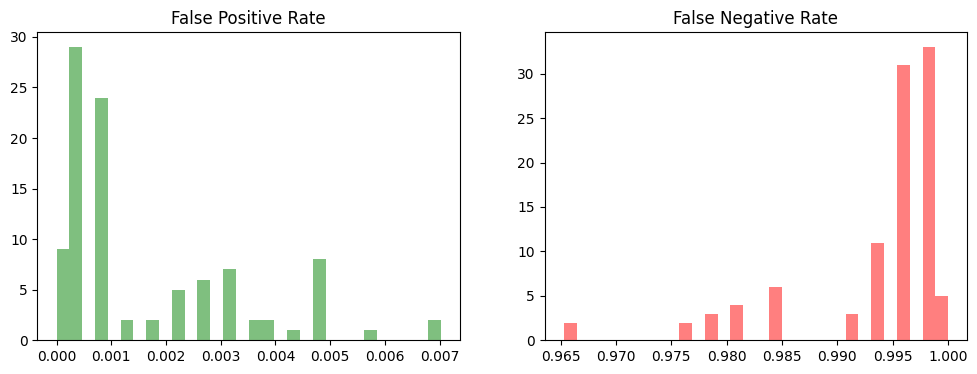

In [18]:
data = data_orig

orig_FPR = data['FPR']
orig_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

**Random Undersampling:**

SRS Random Undersampling performance:

Error type: FPR
Mean: 0.1999582967490781
Variance: 0.0024788539918880795
Variance of estimate: 1.2394269959440397e-05
Standard error: 0.003520549667231013
95% Confidence Interval:  [ 0.19305801940130532 ,  0.2068585740968509 ]
-----------------------------
Error type: FNR
Mean: 0.5168221258013667
Variance: 0.0065864491925425915
Variance of estimate: 3.2932245962712954e-05
Standard error: 0.00573866238445101
95% Confidence Interval:  [ 0.5055743475278427 ,  0.5280699040748906 ]
-----------------------------


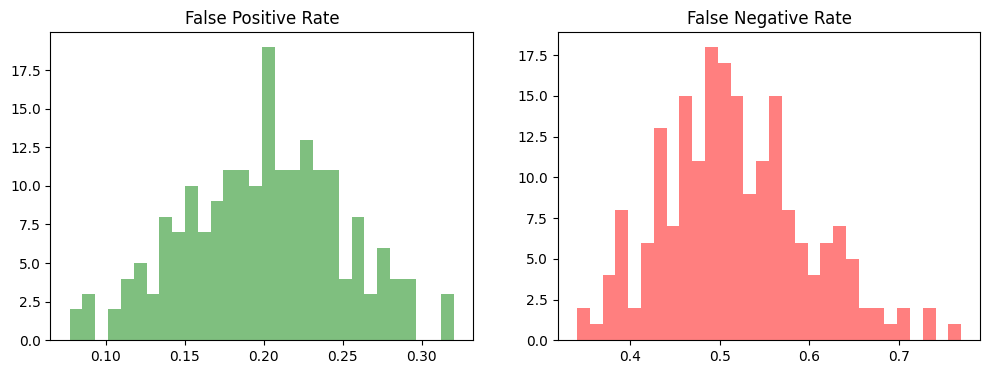

In [19]:
data = data_SRS

SRS_FPR = data['FPR']
SRS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

SRSwR undersampling performance:

Error type: FPR
Mean: 0.1927897278295478
Variance: 0.0027440127929891267
Variance of estimate: 1.3720063964945634e-05
Standard error: 0.003704060469936423
95% Confidence Interval:  [ 0.18552976930847243 ,  0.2000496863506232 ]
-----------------------------
Error type: FNR
Mean: 0.5549349240690781
Variance: 0.008488924620545315
Variance of estimate: 4.244462310272658e-05
Standard error: 0.006514953806645645
95% Confidence Interval:  [ 0.5421656146080526 ,  0.5677042335301036 ]
-----------------------------


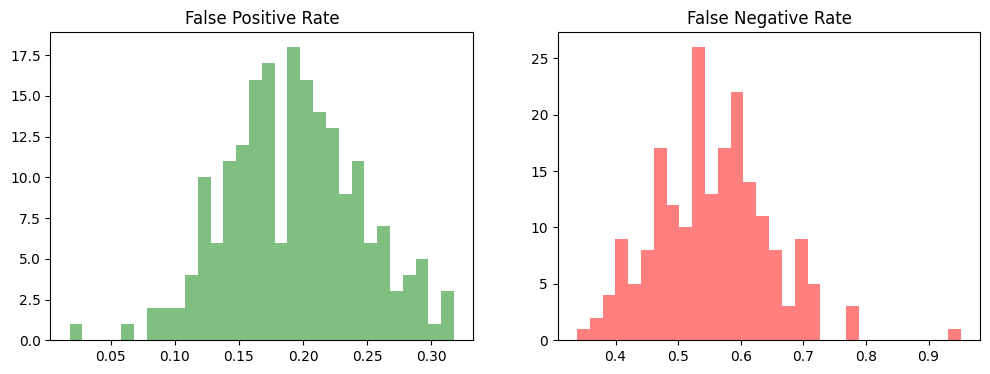

In [20]:
data = data_SRSwR

SRSwR_FPR = data['FPR']
SRSwR_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Undersampling performance:

Error type: FPR
Mean: 0.19181079894280068
Variance: 0.0019776359412422622
Variance of estimate: 9.888179706211311e-06
Standard error: 0.003144547615510268
95% Confidence Interval:  [ 0.18564748561640054 ,  0.1979741122692008 ]
-----------------------------
Error type: FNR
Mean: 0.5374078090973969
Variance: 0.007037318026404858
Variance of estimate: 3.5186590132024293e-05
Standard error: 0.0059318285656300195
95% Confidence Interval:  [ 0.5257814251087621 ,  0.5490341930860317 ]
-----------------------------


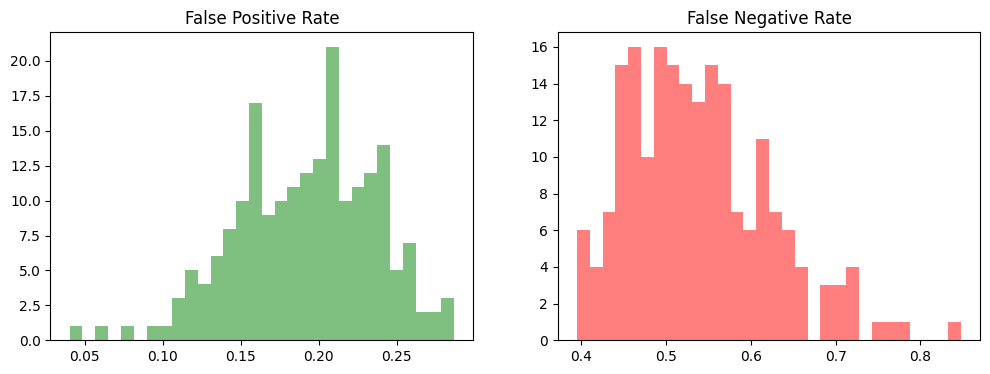

In [21]:
data = data_Sy

Sy_FPR = data['FPR']
Sy_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Multiple Systematic undersampling performance:

Error type: FPR
Mean: 0.1896136962342932
Variance: 0.002994951647903014
Variance of estimate: 1.4974758239515069e-05
Standard error: 0.0038697232768655524
95% Confidence Interval:  [ 0.18202903861163672 ,  0.19719835385694967 ]
-----------------------------
Error type: FNR
Mean: 0.5561930585669089
Variance: 0.009679591937623954
Variance of estimate: 4.839795968811977e-05
Standard error: 0.00695686421371869
95% Confidence Interval:  [ 0.5425576047080203 ,  0.5698285124257976 ]
-----------------------------


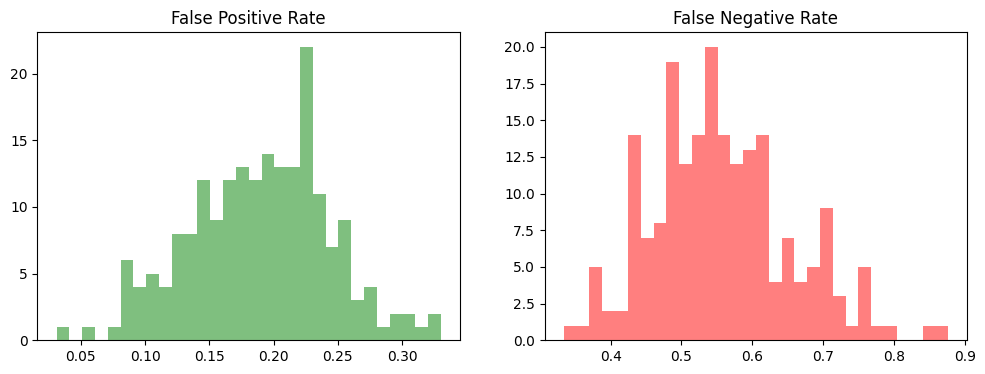

In [22]:
data = data_Sym

Sym_FPR = data['FPR']
Sym_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

**Random Oversampling:**

SRS Oversampling performance:

Error type: FPR
Mean: 0.18227611939663738
Variance: 0.0024123145519958722
Variance of estimate: 1.2061572759979361e-05
Standard error: 0.003472977506402735
95% Confidence Interval:  [ 0.17546908348408802 ,  0.18908315530918673 ]
-----------------------------
Error type: FNR
Mean: 0.5688394793925814
Variance: 0.008393848706210226
Variance of estimate: 4.196924353105113e-05
Standard error: 0.006478367350733603
95% Confidence Interval:  [ 0.5561418793851435 ,  0.5815370794000193 ]
-----------------------------


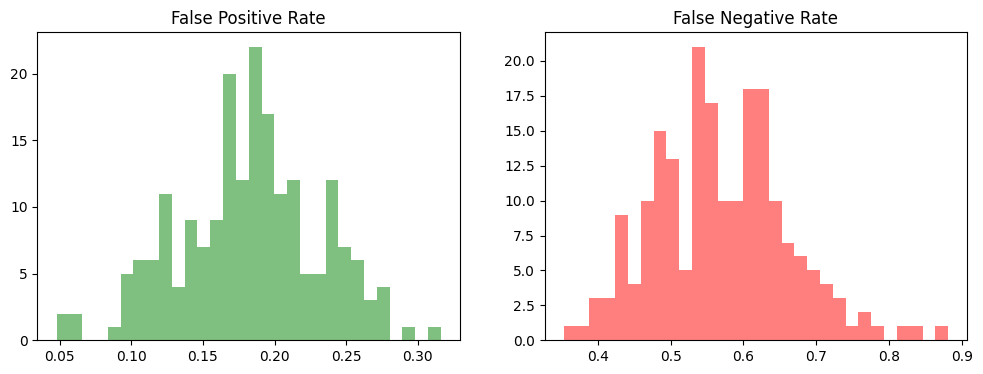

In [23]:
data = data_SRS_ROS

SRS_ROS_FPR = data['FPR']
SRS_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Resampling performance:

Error type: FPR
Mean: 0.1748924495235996
Variance: 0.0021436155976441618
Variance of estimate: 1.0718077988220809e-05
Standard error: 0.0032738475817027293
95% Confidence Interval:  [ 0.16847570826346225 ,  0.18130919078373697 ]
-----------------------------
Error type: FNR
Mean: 0.5806399132354122
Variance: 0.008470788664257432
Variance of estimate: 4.235394332128716e-05
Standard error: 0.006507990728426644
95% Confidence Interval:  [ 0.5678842514076959 ,  0.5933955750631285 ]
-----------------------------


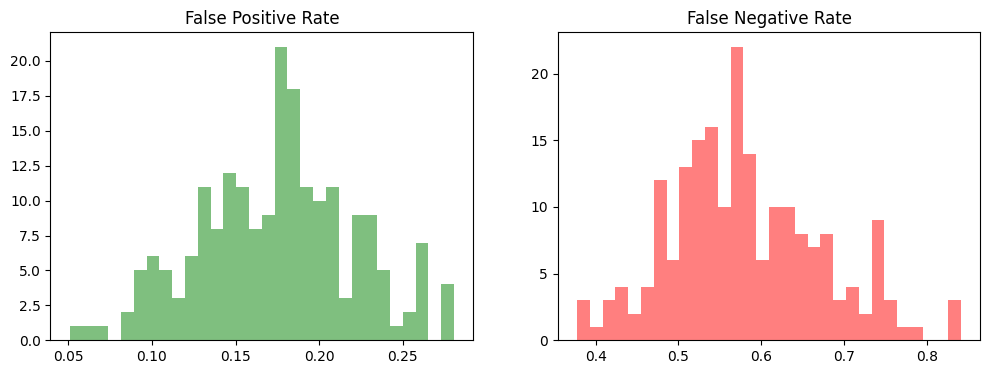

In [24]:
data = data_Sy_ROS

Sy_ROS_FPR = data['FPR']
Sy_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

In [25]:
FPR = pd.DataFrame()

DF = FPR


DF['SRS_RUS'] = SRS_FPR
DF['SRSwR_RUS'] = SRSwR_FPR
DF['Sy_RUS'] = Sy_FPR
DF['Sy_m_RUS'] = Sym_FPR
DF['SRS_ROS'] = SRS_ROS_FPR
DF['Sy_ROS'] = Sy_ROS_FPR
DF['Orig'] = orig_FPR
FPR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.141352,0.111501,0.205882,0.200615,0.237050,0.127305,0.000000
1,0.157594,0.119403,0.258121,0.211589,0.185250,0.130817,0.000878
2,0.224759,0.111062,0.064969,0.150571,0.153205,0.224320,0.000000
3,0.185250,0.155838,0.158472,0.256804,0.167252,0.231343,0.000878
4,0.159350,0.193591,0.215101,0.228270,0.174276,0.190957,0.000878
...,...,...,...,...,...,...,...
195,0.217296,0.266462,0.211589,0.227831,0.143986,0.176910,NaN
196,0.205882,0.288850,0.172959,0.127305,0.130378,0.183933,NaN
197,0.295874,0.209833,0.219052,0.231782,0.188323,0.092186,NaN
198,0.163740,0.317823,0.144425,0.164179,0.100966,0.210272,NaN


<Axes: title={'center': 'FPR'}>

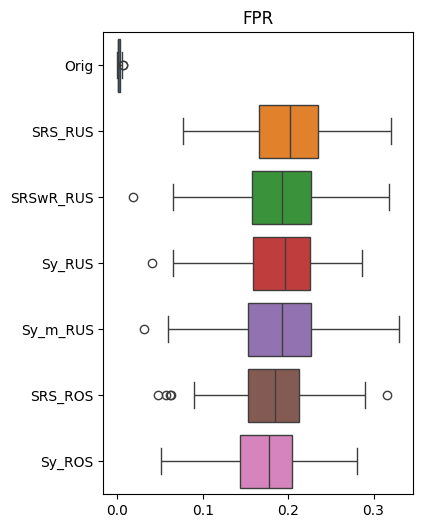

In [26]:
dataset = FPR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FPR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

In [27]:
FNR = pd.DataFrame()

DF = FNR


DF['SRS_RUS'] = SRS_FNR
DF['SRSwR_RUS'] = SRSwR_FNR
DF['Sy_RUS'] = Sy_FNR
DF['Sy_m_RUS'] = Sym_FNR
DF['SRS_ROS'] = SRS_ROS_FNR
DF['Sy_ROS'] = Sy_ROS_FNR
DF['Orig'] = orig_FNR
FNR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.596529,0.722343,0.516269,0.511931,0.509761,0.668113,0.997831
1,0.557484,0.700651,0.446855,0.485900,0.583514,0.672451,0.997831
2,0.442516,0.715835,0.776573,0.590022,0.639913,0.516269,0.997831
3,0.518438,0.629067,0.596529,0.449024,0.603037,0.507592,0.997831
4,0.561822,0.579176,0.501085,0.466377,0.600868,0.563991,0.995662
...,...,...,...,...,...,...,...
195,0.485900,0.444685,0.481562,0.483731,0.624729,0.557484,NaN
196,0.501085,0.407809,0.546638,0.672451,0.648590,0.533623,NaN
197,0.388286,0.524946,0.466377,0.481562,0.548807,0.744035,NaN
198,0.566161,0.360087,0.613883,0.603037,0.728850,0.472885,NaN


<Axes: title={'center': 'FNR'}>

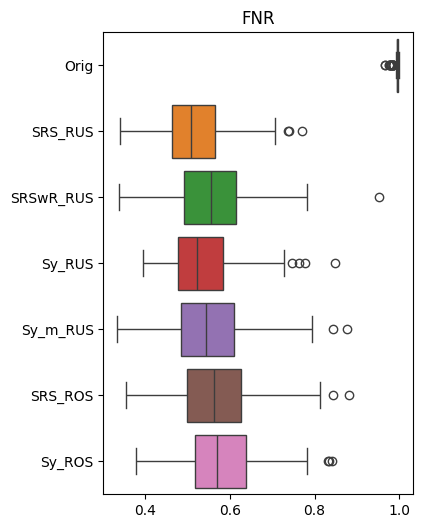

In [28]:
dataset = FNR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FNR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

## "Adult" Data:

In [29]:
path_to_data = 'https://raw.githubusercontent.com/AndreiAf02/Resolving_Data_Imbalance/main/Transfer_Learning/Adult/'

In [30]:
data_orig = pd.read_csv(path_to_data+ "Adult_Imbalanced_Fine_Tuning_5_20.csv", sep=",", header=0)
data_SRS = pd.read_csv(path_to_data+ "Adult_SRS_Fine_Tuning_Extension.csv", sep=",", header=0)
data_SRSwR = pd.read_csv(path_to_data+ "Adult_SRSwR_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sy = pd.read_csv(path_to_data+ "Adult_Sy_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sym = pd.read_csv(path_to_data+ "Adult_Sy_multi_Fine_Tuning_Extension.csv", sep=",", header=0)
data_SRS_ROS = pd.read_csv(path_to_data+ "Adult_SRS_ROS_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sy_ROS = pd.read_csv(path_to_data+ "Adult_Sy_ROS_Fine_Tuning_Extension.csv", sep=",", header=0)

data_Sy_ROS

,Unnamed: 0,FPR,FNR
0,0,0.122135,0.440580
1,1,0.139685,0.408696
2,2,0.067693,0.553623
3,3,0.182307,0.342029
4,4,0.125358,0.428986
...,...,...,...
195,95,0.198782,0.324638
196,96,0.110315,0.510145
197,97,0.117479,0.478261
198,98,0.169413,0.376812


Original (imbalanced) data performance:

Error type: FPR
Mean: 0.005225644699140347
Variance: 1.7252368576198015e-05
Variance of estimate: 1.7252368576198016e-07
Standard error: 0.0004153597064737746
95% Confidence Interval:  [ 0.004411539674451749 ,  0.006039749723828945 ]
-----------------------------
Error type: FNR
Mean: 0.8940869565217392
Variance: 0.0033284612561235135
Variance of estimate: 3.3284612561235136e-05
Standard error: 0.005769281806363348
95% Confidence Interval:  [ 0.882779164181267 ,  0.9053947488622114 ]
-----------------------------


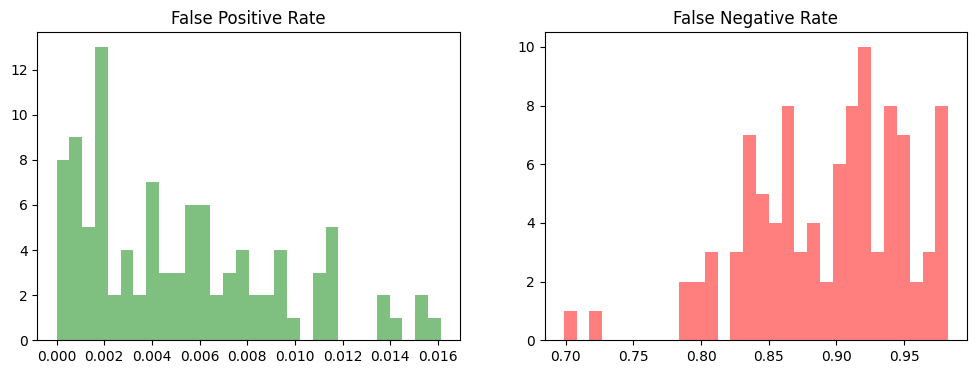

In [31]:
data = data_orig

orig_FPR = data['FPR']
orig_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

**Random Undersampling:**

SRS Random Undersampling performance:

Error type: FPR
Mean: 0.13893803724932663
Variance: 0.0016951547339664262
Variance of estimate: 8.47577366983213e-06
Standard error: 0.002911318201405015
95% Confidence Interval:  [ 0.1332318535745728 ,  0.14464422092408047 ]
-----------------------------
Error type: FNR
Mean: 0.4318260869623189
Variance: 0.008480711476715483
Variance of estimate: 4.240355738357742e-05
Standard error: 0.006511801393130584
95% Confidence Interval:  [ 0.41906295623178297 ,  0.4445892176928548 ]
-----------------------------


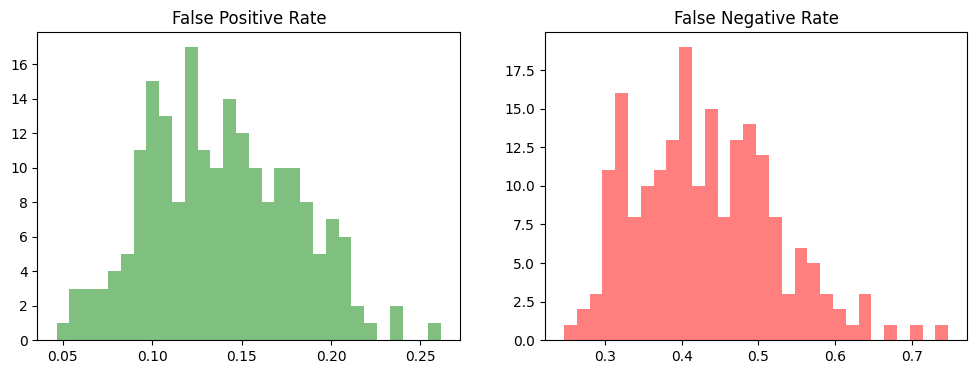

In [32]:
data = data_SRS

SRS_FPR = data['FPR']
SRS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

SRSwR undersampling performance:

Error type: FPR
Mean: 0.14452542979434096
Variance: 0.0015380476162658236
Variance of estimate: 7.690238081329117e-06
Standard error: 0.0027731278516017104
95% Confidence Interval:  [ 0.1390900992052016 ,  0.14996076038348033 ]
-----------------------------
Error type: FNR
Mean: 0.40443478261246374
Variance: 0.0049978867236583815
Variance of estimate: 2.498943361829191e-05
Standard error: 0.004998943250157168
95% Confidence Interval:  [ 0.3946368538421557 ,  0.4142327113827718 ]
-----------------------------


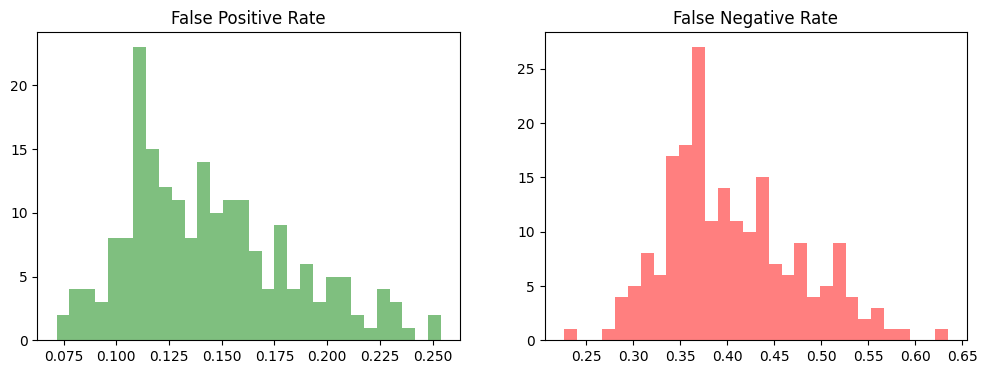

In [33]:
data = data_SRSwR

SRSwR_FPR = data['FPR']
SRSwR_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Undersampling performance:

Error type: FPR
Mean: 0.1441672636011461
Variance: 0.0024720189051769307
Variance of estimate: 1.2360094525884653e-05
Standard error: 0.003515692609697932
95% Confidence Interval:  [ 0.13727650608613814 ,  0.15105802111615405 ]
-----------------------------
Error type: FNR
Mean: 0.41921739130782604
Variance: 0.010174317080994035
Variance of estimate: 5.0871585404970174e-05
Standard error: 0.007132431941839345
95% Confidence Interval:  [ 0.4052378247018209 ,  0.43319695791383117 ]
-----------------------------


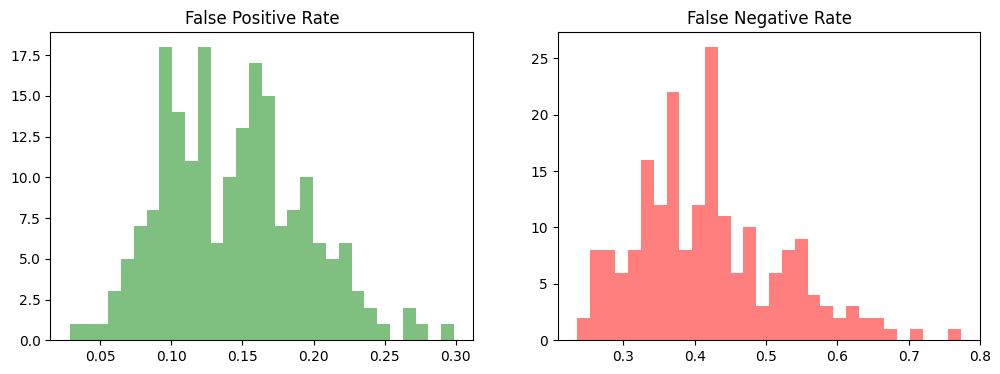

In [34]:
data = data_Sy

Sy_FPR = data['FPR']
Sy_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Multiple Systematic undersampling performance:

Error type: FPR
Mean: 0.1498943409788968
Variance: 0.001686195834019832
Variance of estimate: 8.430979170099161e-06
Standard error: 0.0029036148453435006
95% Confidence Interval:  [ 0.14420325588202354 ,  0.15558542607577008 ]
-----------------------------
Error type: FNR
Mean: 0.4764492753594202
Variance: 0.015846038635582017
Variance of estimate: 7.923019317791008e-05
Standard error: 0.008901134375904573
95% Confidence Interval:  [ 0.45900305198264724 ,  0.4938954987361932 ]
-----------------------------


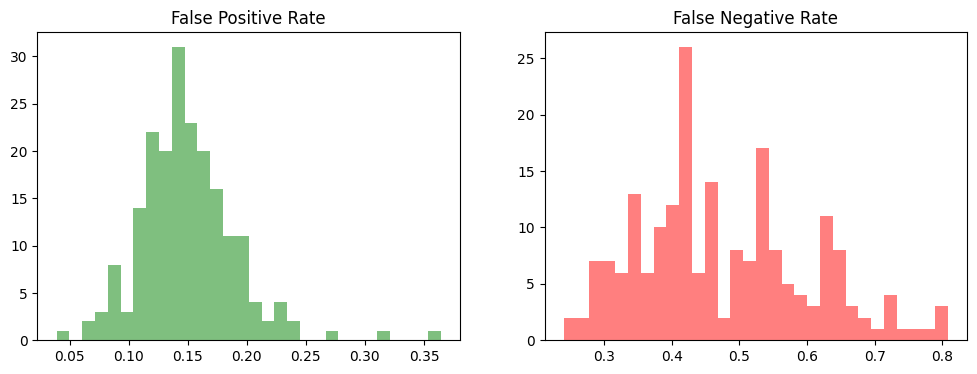

In [35]:
data = data_Sym

Sym_FPR = data['FPR']
Sym_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

**Random Oversampling:**

SRS Oversampling performance:

Error type: FPR
Mean: 0.1309509312282521
Variance: 0.0009697044620618898
Variance of estimate: 4.848522310309449e-06
Standard error: 0.0022019360368342785
95% Confidence Interval:  [ 0.1266351365960569 ,  0.1352667258604473 ]
-----------------------------
Error type: FNR
Mean: 0.37765217391507244
Variance: 0.004463957257622658
Variance of estimate: 2.2319786288113288e-05
Standard error: 0.0047243821064889835
95% Confidence Interval:  [ 0.368392384986354 ,  0.38691196284379087 ]
-----------------------------


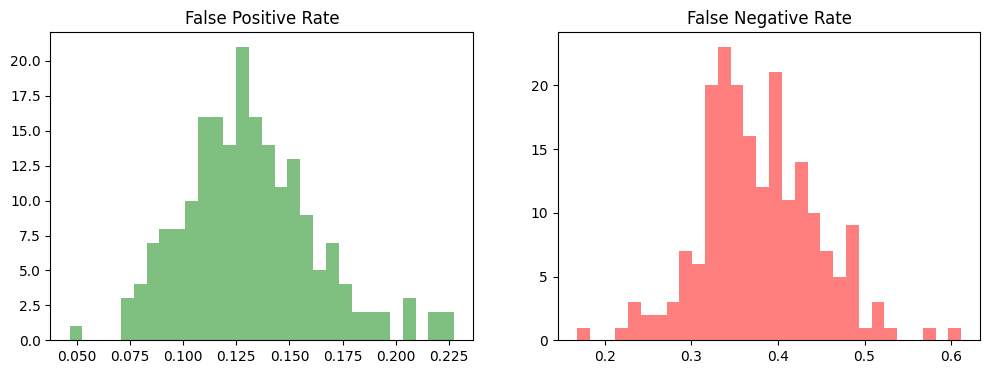

In [36]:
data = data_SRS_ROS

SRS_ROS_FPR = data['FPR']
SRS_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Resampling performance:

Error type: FPR
Mean: 0.12716332377382517
Variance: 0.000975545095369464
Variance of estimate: 4.8777254768473205e-06
Standard error: 0.002208557329309638
95% Confidence Interval:  [ 0.12283455140837828 ,  0.13149209613927207 ]
-----------------------------
Error type: FNR
Mean: 0.38913043478376813
Variance: 0.0057734376560897365
Variance of estimate: 2.8867188280448683e-05
Standard error: 0.0053728193977137075
95% Confidence Interval:  [ 0.37859970876424925 ,  0.399661160803287 ]
-----------------------------


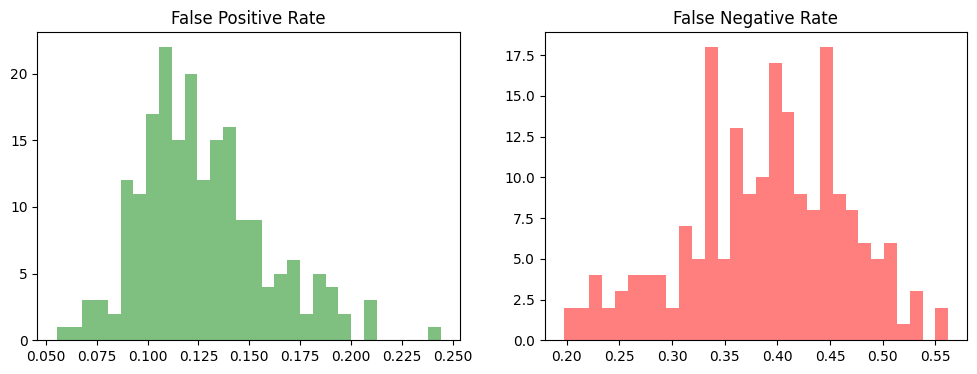

In [37]:
data = data_Sy_ROS

Sy_ROS_FPR = data['FPR']
Sy_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

In [38]:
FPR = pd.DataFrame()

DF = FPR


DF['SRS_RUS'] = SRS_FPR
DF['SRSwR_RUS'] = SRSwR_FPR
DF['Sy_RUS'] = Sy_FPR
DF['Sy_m_RUS'] = Sym_FPR
DF['SRS_ROS'] = SRS_ROS_FPR
DF['Sy_ROS'] = Sy_ROS_FPR
DF['Orig'] = orig_FPR
FPR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.160817,0.142908,0.093123,0.108883,0.114613,0.122135,0.009670
1,0.143983,0.172636,0.093481,0.313754,0.116404,0.139685,0.000000
2,0.114971,0.113181,0.090616,0.087034,0.128223,0.067693,0.004656
3,0.172994,0.120702,0.123926,0.124284,0.110315,0.182307,0.000000
4,0.149355,0.118911,0.126791,0.069484,0.222779,0.125358,0.001433
...,...,...,...,...,...,...,...
195,0.151504,0.109957,0.179083,0.272206,0.167980,0.198782,NaN
196,0.177650,0.177292,0.155086,0.230301,0.157235,0.110315,NaN
197,0.132880,0.186963,0.159742,0.114613,0.129298,0.117479,NaN
198,0.142908,0.093481,0.221705,0.201648,0.103868,0.169413,NaN


<Axes: title={'center': 'FPR'}>

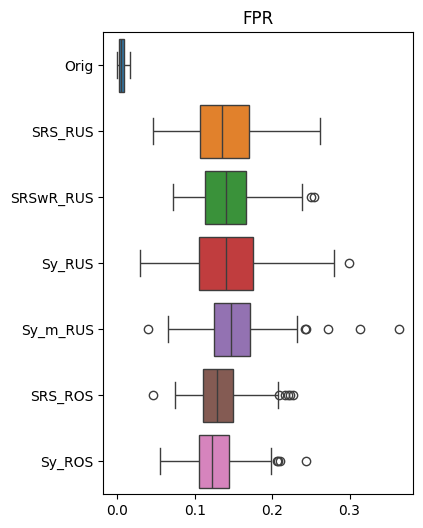

In [39]:
dataset = FPR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FPR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

In [40]:
FNR = pd.DataFrame()

DF = FNR


DF['SRS_RUS'] = SRS_FNR
DF['SRSwR_RUS'] = SRSwR_FNR
DF['Sy_RUS'] = Sy_FNR
DF['Sy_m_RUS'] = Sym_FNR
DF['SRS_ROS'] = SRS_ROS_FNR
DF['Sy_ROS'] = Sy_ROS_FNR
DF['Orig'] = orig_FNR
FNR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.446377,0.484058,0.371014,0.649275,0.391304,0.440580,0.866667
1,0.469565,0.437681,0.373913,0.339130,0.339130,0.408696,0.982609
2,0.515942,0.544928,0.373913,0.730435,0.324638,0.553623,0.927536
3,0.408696,0.515942,0.318841,0.631884,0.350725,0.342029,0.976812
4,0.455072,0.524638,0.310145,0.808696,0.237681,0.428986,0.924638
...,...,...,...,...,...,...,...
195,0.339130,0.440580,0.344928,0.240580,0.336232,0.324638,NaN
196,0.313043,0.307246,0.405797,0.275362,0.365217,0.510145,NaN
197,0.371014,0.318841,0.394203,0.440580,0.394203,0.478261,NaN
198,0.350725,0.475362,0.286957,0.295652,0.472464,0.376812,NaN


<Axes: title={'center': 'FNR'}>

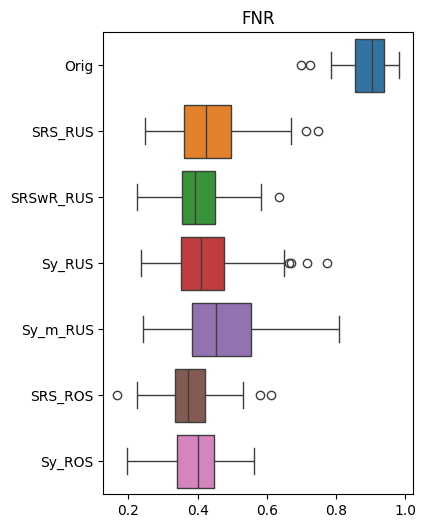

In [41]:
dataset = FNR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FNR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

## "Bank Marketing" Data:

In [42]:
path_to_data = 'https://raw.githubusercontent.com/AndreiAf02/Resolving_Data_Imbalance/main/Transfer_Learning/Bank_Marketing/'

In [43]:
data_orig = pd.read_csv(path_to_data+ "Bank_Imbalanced_Fine_Tuning_5_20.csv", sep=",", header=0)
data_SRS = pd.read_csv(path_to_data+ "Bank_SRS_Fine_Tuning_Extension.csv", sep=",", header=0)
data_SRSwR = pd.read_csv(path_to_data+ "Bank_SRSwR_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sy = pd.read_csv(path_to_data+ "Bank_Sy_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sym = pd.read_csv(path_to_data+ "Bank_Sy_multi_Fine_Tuning_Extension.csv", sep=",", header=0)
data_SRS_ROS = pd.read_csv(path_to_data+ "Bank_SRS_ROS_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sy_ROS = pd.read_csv(path_to_data+ "Bank_Sy_ROS_Fine_Tuning_Extension.csv", sep=",", header=0)

data_Sy_ROS

,Unnamed: 0,FPR,FNR
0,0,0.174014,0.415225
1,1,0.162413,0.446367
2,2,0.160093,0.460208
3,3,0.185615,0.384083
4,4,0.156999,0.453287
...,...,...,...
195,95,0.197989,0.418685
196,96,0.159319,0.529412
197,97,0.139985,0.550173
198,98,0.197216,0.442907


Original (imbalanced) data performance:

Error type: FPR
Mean: 0.0028074245939674926
Variance: 8.261040393726939e-06
Variance of estimate: 8.261040393726938e-08
Standard error: 0.00028742025665785874
95% Confidence Interval:  [ 0.0022440808909180896 ,  0.0033707682970168956 ]
-----------------------------
Error type: FNR
Mean: 0.9908304498269895
Variance: 7.168704562174428e-05
Variance of estimate: 7.168704562174427e-07
Standard error: 0.0008466820278105841
95% Confidence Interval:  [ 0.9891709530524808 ,  0.9924899466014983 ]
-----------------------------


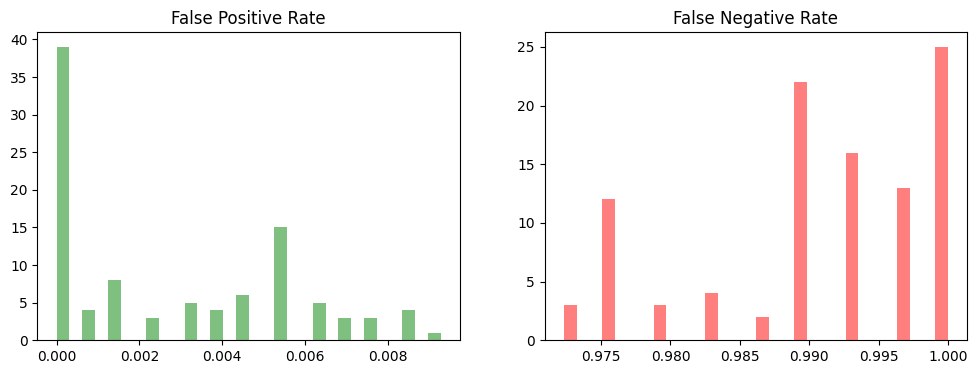

In [44]:
data = data_orig

orig_FPR = data['FPR']
orig_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

**Random Undersampling:**

SRS Random Undersampling performance:

Error type: FPR
Mean: 0.2105065738581361
Variance: 0.000892016779949577
Variance of estimate: 4.460083899747885e-06
Standard error: 0.0021118910719418946
95% Confidence Interval:  [ 0.20636726735712999 ,  0.2146458803591422 ]
-----------------------------
Error type: FNR
Mean: 0.4372491349540138
Variance: 0.0031900234025352614
Variance of estimate: 1.5950117012676307e-05
Standard error: 0.003993759759008585
95% Confidence Interval:  [ 0.429421365826357 ,  0.4450769040816706 ]
-----------------------------


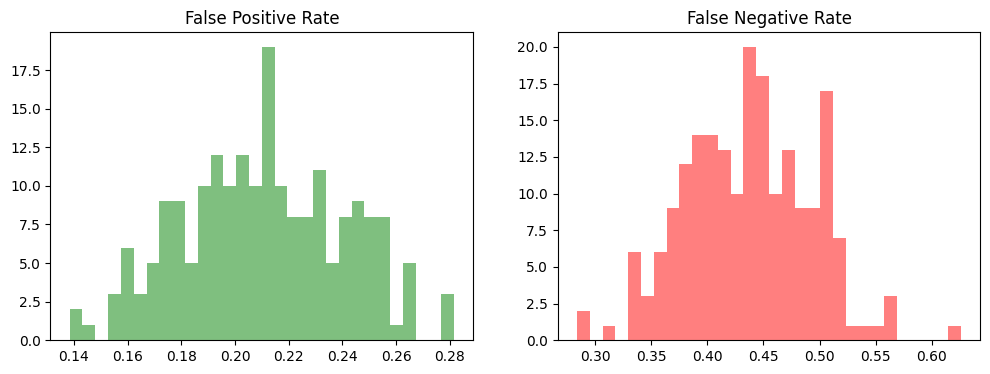

In [45]:
data = data_SRS

SRS_FPR = data['FPR']
SRS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

SRSwR undersampling performance:

Error type: FPR
Mean: 0.21630703789582362
Variance: 0.0011361511365219552
Variance of estimate: 5.6807556826097755e-06
Standard error: 0.0023834335909795716
95% Confidence Interval:  [ 0.21163550805750367 ,  0.22097856773414357 ]
-----------------------------
Error type: FNR
Mean: 0.4534602076224567
Variance: 0.005063060297072481
Variance of estimate: 2.5315301485362402e-05
Standard error: 0.005031431355525225
95% Confidence Interval:  [ 0.44359860216562724 ,  0.46332181307928616 ]
-----------------------------


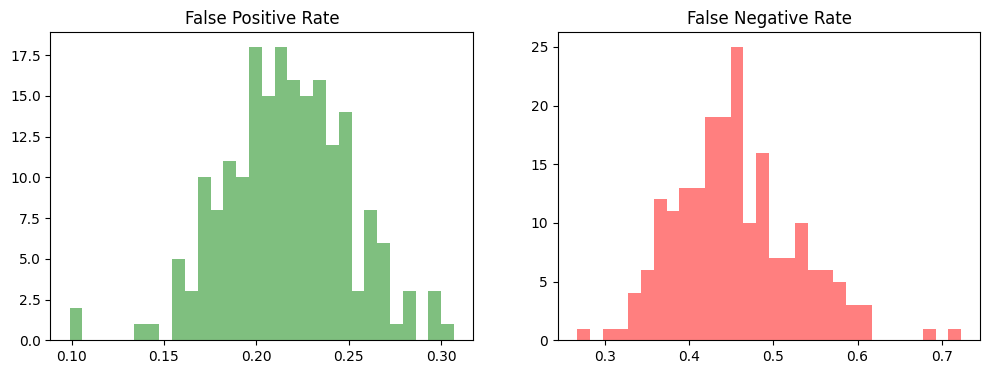

In [46]:
data = data_SRSwR

SRSwR_FPR = data['FPR']
SRSwR_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Undersampling performance:

Error type: FPR
Mean: 0.205421500389184
Variance: 0.0009454629310143288
Variance of estimate: 4.727314655071644e-06
Standard error: 0.002174238867988438
95% Confidence Interval:  [ 0.20115999220792666 ,  0.20968300857044134 ]
-----------------------------
Error type: FNR
Mean: 0.4486332179999134
Variance: 0.004603012606893409
Variance of estimate: 2.3015063034467046e-05
Standard error: 0.004797401696175446
95% Confidence Interval:  [ 0.4392303106754095 ,  0.4580361253244173 ]
-----------------------------


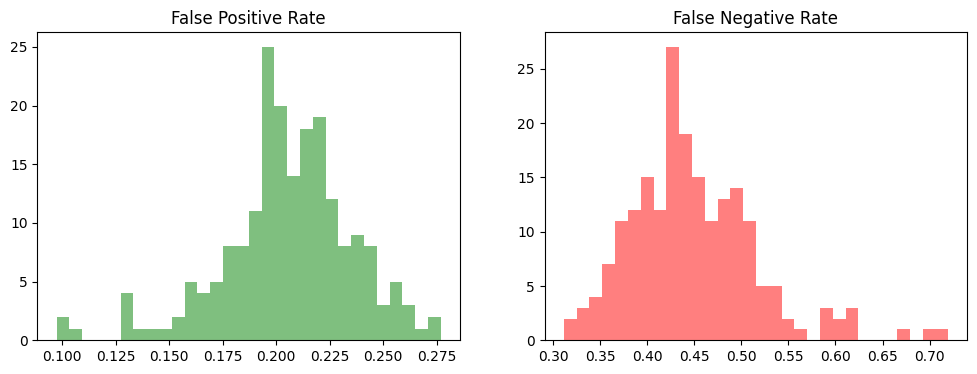

In [47]:
data = data_Sy

Sy_FPR = data['FPR']
Sy_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Multiple Systematic undersampling performance:

Error type: FPR
Mean: 0.13159706110915312
Variance: 0.0028657952106411902
Variance of estimate: 1.4328976053205952e-05
Standard error: 0.0037853633977738455
95% Confidence Interval:  [ 0.12417774884951638 ,  0.13901637336878986 ]
-----------------------------
Error type: FNR
Mean: 0.693200692054879
Variance: 0.010268085619548667
Variance of estimate: 5.134042809774334e-05
Standard error: 0.0071652235204313994
95% Confidence Interval:  [ 0.6791568539548335 ,  0.7072445301549245 ]
-----------------------------


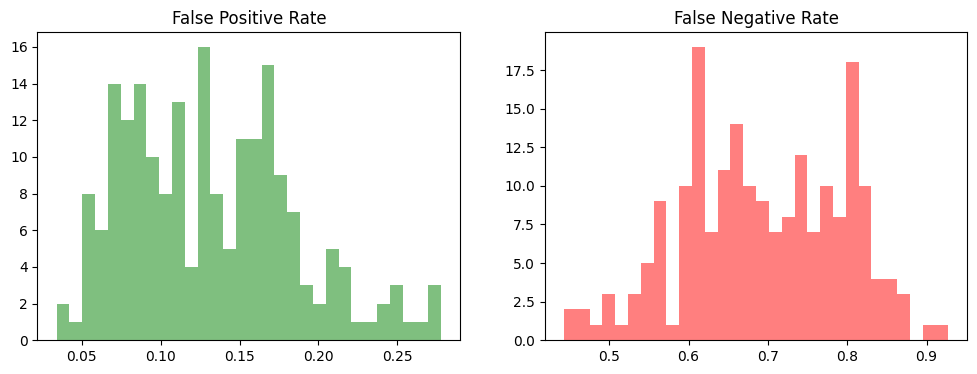

In [48]:
data = data_Sym

Sym_FPR = data['FPR']
Sym_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

**Random Oversampling:**

SRS Oversampling performance:

Error type: FPR
Mean: 0.1643735498952629
Variance: 0.001414663821963662
Variance of estimate: 7.07331910981831e-06
Standard error: 0.0026595712266864204
95% Confidence Interval:  [ 0.1591607902909575 ,  0.1695863094995683 ]
-----------------------------
Error type: FNR
Mean: 0.5084083044973355
Variance: 0.009937080189145001
Variance of estimate: 4.9685400945725e-05
Standard error: 0.007048787196796694
95% Confidence Interval:  [ 0.494592681591614 ,  0.522223927403057 ]
-----------------------------


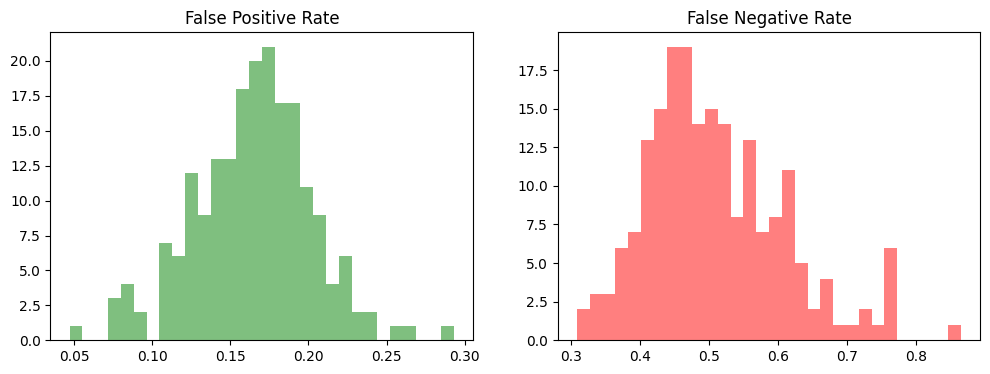

In [49]:
data = data_SRS_ROS

SRS_ROS_FPR = data['FPR']
SRS_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Resampling performance:

Error type: FPR
Mean: 0.19519721577822113
Variance: 0.001092990139588154
Variance of estimate: 5.46495069794077e-06
Standard error: 0.002337723400648753
95% Confidence Interval:  [ 0.19061527791294958 ,  0.1997791536434927 ]
-----------------------------
Error type: FNR
Mean: 0.4267993079600692
Variance: 0.006364192160161239
Variance of estimate: 3.1820960800806195e-05
Standard error: 0.005641007073280993
95% Confidence Interval:  [ 0.4157429340964385 ,  0.43785568182369994 ]
-----------------------------


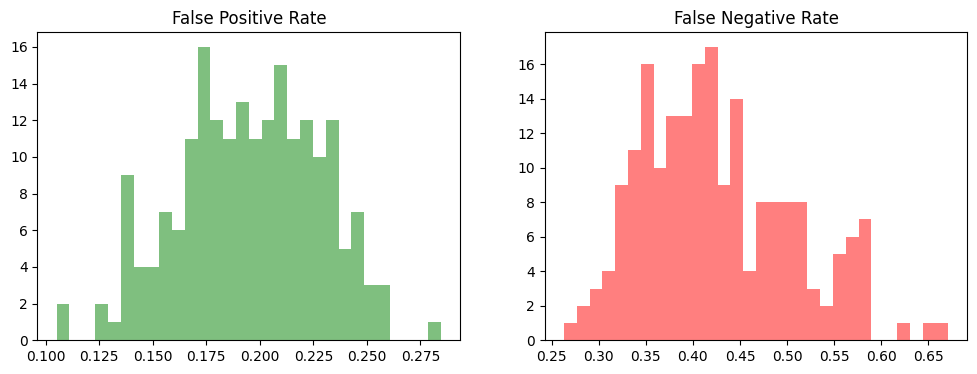

In [50]:
data = data_Sy_ROS

Sy_ROS_FPR = data['FPR']
Sy_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

In [51]:
FPR = pd.DataFrame()

DF = FPR


DF['SRS_RUS'] = SRS_FPR
DF['SRSwR_RUS'] = SRSwR_FPR
DF['Sy_RUS'] = Sy_FPR
DF['Sy_m_RUS'] = Sym_FPR
DF['SRS_ROS'] = SRS_ROS_FPR
DF['Sy_ROS'] = Sy_ROS_FPR
DF['Orig'] = orig_FPR
FPR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.242846,0.307038,0.197216,0.057231,0.199536,0.174014,0.0
1,0.180974,0.215004,0.189482,0.064965,0.203403,0.162413,0.0
2,0.192575,0.184841,0.221191,0.085073,0.205723,0.160093,0.0
3,0.164733,0.198763,0.220418,0.081980,0.168600,0.185615,0.0
4,0.173241,0.293890,0.232019,0.093581,0.168600,0.156999,0.0
...,...,...,...,...,...,...,...
195,0.245166,0.198763,0.199536,0.214230,0.293117,0.197989,NaN
196,0.233565,0.171694,0.247486,0.109049,0.220418,0.159319,NaN
197,0.246713,0.180974,0.255220,0.180201,0.167053,0.139985,NaN
198,0.210363,0.181748,0.186388,0.169374,0.163960,0.197216,NaN


<Axes: title={'center': 'FPR'}>

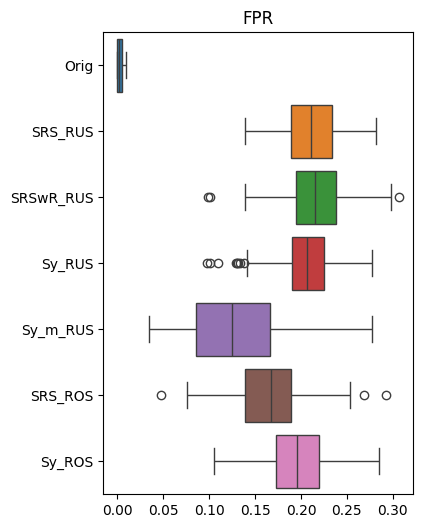

In [52]:
dataset = FPR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FPR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

In [53]:
FNR = pd.DataFrame()

DF = FNR


DF['SRS_RUS'] = SRS_FNR
DF['SRSwR_RUS'] = SRSwR_FNR
DF['Sy_RUS'] = Sy_FNR
DF['Sy_m_RUS'] = Sym_FNR
DF['SRS_ROS'] = SRS_ROS_FNR
DF['Sy_ROS'] = Sy_ROS_FNR
DF['Orig'] = orig_FNR
FNR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.352941,0.359862,0.498270,0.851211,0.404844,0.415225,1.0
1,0.439446,0.487889,0.512111,0.844291,0.391003,0.446367,1.0
2,0.432526,0.529412,0.439446,0.813149,0.394464,0.460208,1.0
3,0.491349,0.498270,0.435986,0.813149,0.467128,0.384083,1.0
4,0.446367,0.370242,0.415225,0.785467,0.467128,0.453287,1.0
...,...,...,...,...,...,...,...
195,0.397924,0.532872,0.453287,0.546713,0.321799,0.418685,NaN
196,0.418685,0.577855,0.349481,0.698962,0.418685,0.529412,NaN
197,0.401384,0.557093,0.328720,0.598616,0.505190,0.550173,NaN
198,0.456747,0.560554,0.491349,0.605536,0.508651,0.442907,NaN


<Axes: title={'center': 'FNR'}>

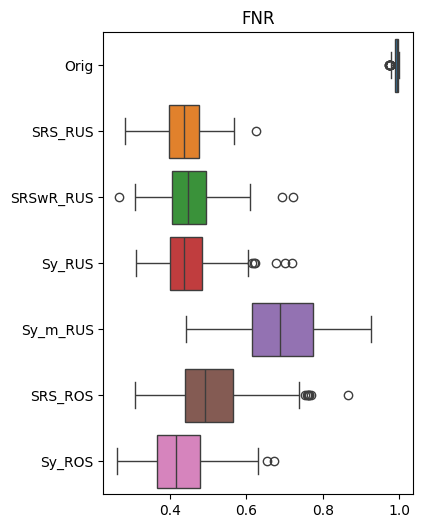

In [54]:
dataset = FNR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FNR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

## "Default of Credit Card Clients" Data:

In [55]:
path_to_data = 'https://raw.githubusercontent.com/AndreiAf02/Resolving_Data_Imbalance/main/Transfer_Learning/Credit_Default/'

In [56]:
data_orig = pd.read_csv(path_to_data+ "Credit_Imbalanced_Fine_Tuning_5_20.csv", sep=",", header=0)
data_SRS = pd.read_csv(path_to_data+ "Credit_SRS_Fine_Tuning_Extension.csv", sep=",", header=0)
data_SRSwR = pd.read_csv(path_to_data+ "Credit_SRSwR_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sy = pd.read_csv(path_to_data+ "Credit_Sy_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sym = pd.read_csv(path_to_data+ "Credit_Sy_multi_Fine_Tuning_Extension.csv", sep=",", header=0)
data_SRS_ROS = pd.read_csv(path_to_data+ "Credit_SRS_ROS_Fine_Tuning_Extension.csv", sep=",", header=0)
data_Sy_ROS = pd.read_csv(path_to_data+ "Credit_Sy_ROS_Fine_Tuning_Extension.csv", sep=",", header=0)

data_Sy_ROS

,Unnamed: 0,FPR,FNR
0,0,0.121641,0.572687
1,1,0.120226,0.581498
2,2,0.118812,0.585903
3,3,0.121641,0.581498
4,4,0.123055,0.572687
...,...,...,...
195,95,0.124470,0.581498
196,96,0.124470,0.585903
197,97,0.123055,0.585903
198,98,0.124470,0.577093


Original (imbalanced) data performance:

Error type: FPR
Mean: 0.07217821782178213
Variance: 0.00025019495281514446
Variance of estimate: 2.5019495281514446e-06
Standard error: 0.0015817552048757243
95% Confidence Interval:  [ 0.06907797762022572 ,  0.07527845802333855 ]
-----------------------------
Error type: FNR
Mean: 0.6823348017621145
Variance: 0.0012815750903041564
Variance of estimate: 1.2815750903041564e-05
Standard error: 0.003579909342852353
95% Confidence Interval:  [ 0.6753181794501238 ,  0.6893514240741051 ]
-----------------------------


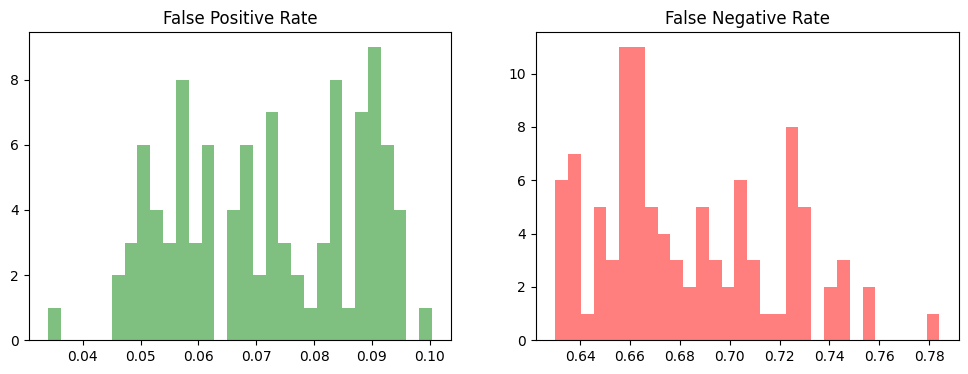

In [57]:
data = data_orig

orig_FPR = data['FPR']
orig_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

**Random Undersampling:**

SRS Random Undersampling performance:

Error type: FPR
Mean: 0.12939886845827434
Variance: 7.397163591645895e-05
Variance of estimate: 3.698581795822948e-07
Standard error: 0.0006081596661916135
95% Confidence Interval:  [ 0.12820687551253876 ,  0.1305908614040099 ]
-----------------------------
Error type: FNR
Mean: 0.5746696035242291
Variance: 0.00016749118489261681
Variance of estimate: 8.37455924463084e-07
Standard error: 0.0009151261795310437
95% Confidence Interval:  [ 0.5728759562123483 ,  0.5764632508361099 ]
-----------------------------


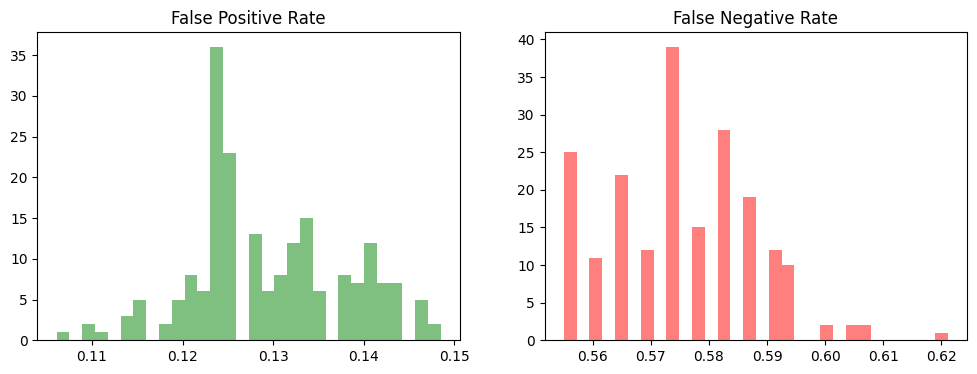

In [58]:
data = data_SRS

SRS_FPR = data['FPR']
SRS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

SRSwR undersampling performance:

Error type: FPR
Mean: 0.10998585573250348
Variance: 2.499729781256735e-05
Variance of estimate: 1.2498648906283675e-07
Standard error: 0.00035353428272635277
95% Confidence Interval:  [ 0.10929292853835983 ,  0.11067878292664714 ]
-----------------------------
Error type: FNR
Mean: 0.6040528634361233
Variance: 0.00010153037695219895
Variance of estimate: 5.076518847609947e-07
Standard error: 0.000712496936667797
95% Confidence Interval:  [ 0.6026563694402545 ,  0.6054493574319921 ]
-----------------------------


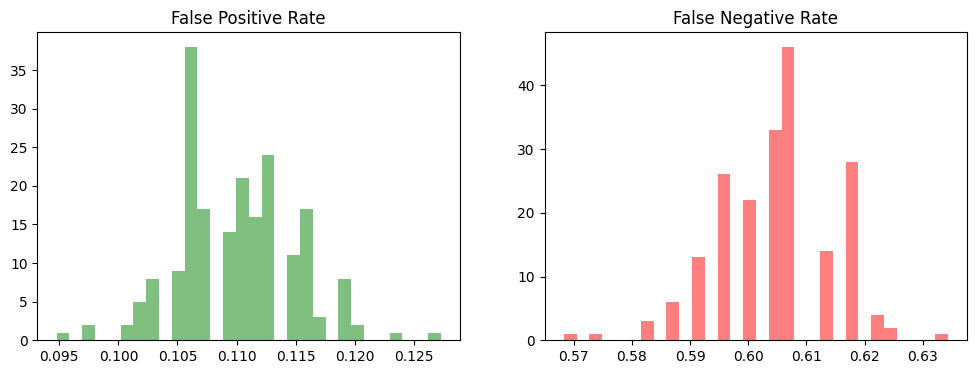

In [59]:
data = data_SRSwR

SRSwR_FPR = data['FPR']
SRSwR_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Undersampling performance:

Error type: FPR
Mean: 0.1160820367764851
Variance: 5.8419853797884156e-05
Variance of estimate: 2.920992689894208e-07
Standard error: 0.0005404620883923504
95% Confidence Interval:  [ 0.11502273108323609 ,  0.11714134246973411 ]
-----------------------------
Error type: FNR
Mean: 0.5914757709251102
Variance: 0.0002741252888674385
Variance of estimate: 1.3706264443371924e-06
Standard error: 0.0011707375642462288
95% Confidence Interval:  [ 0.5891811252991875 ,  0.5937704165510328 ]
-----------------------------


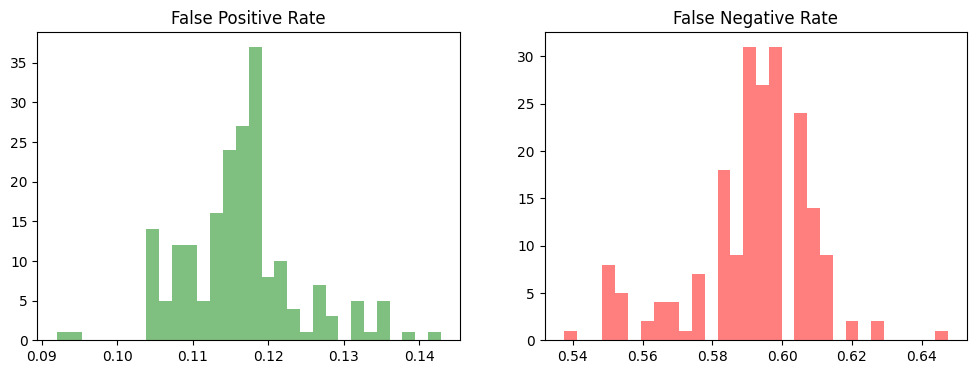

In [60]:
data = data_Sy

Sy_FPR = data['FPR']
Sy_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Multiple Systematic undersampling performance:

Error type: FPR
Mean: 0.1387199434229137
Variance: 5.7282374654029986e-05
Variance of estimate: 2.8641187327014994e-07
Standard error: 0.0005351746194188864
95% Confidence Interval:  [ 0.13767100116885267 ,  0.1397688856769747 ]
-----------------------------
Error type: FNR
Mean: 0.5591409691629956
Variance: 0.00025490598015207516
Variance of estimate: 1.2745299007603758e-06
Standard error: 0.0011289507964301968
95% Confidence Interval:  [ 0.5569282256019924 ,  0.5613537127239988 ]
-----------------------------


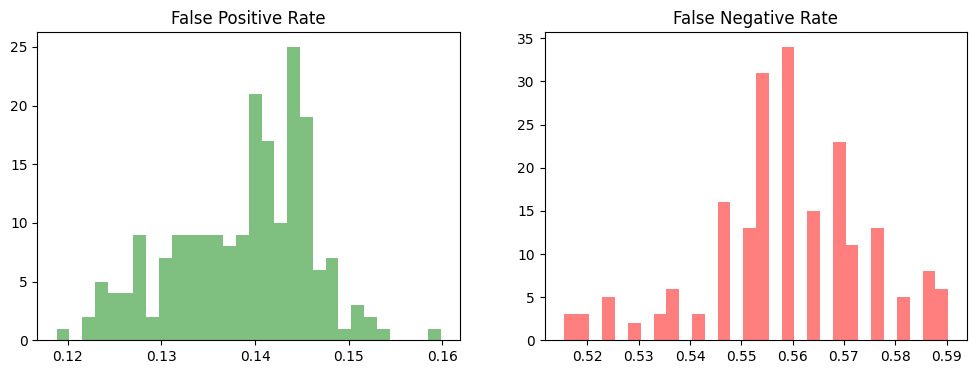

In [61]:
data = data_Sym

Sym_FPR = data['FPR']
Sym_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

**Random Oversampling:**

SRS Oversampling performance:

Error type: FPR
Mean: 0.12195190947666189
Variance: 4.9545817108123494e-05
Variance of estimate: 2.477290855406175e-07
Standard error: 0.0004977239049318582
95% Confidence Interval:  [ 0.12097637062299545 ,  0.12292744833032833 ]
-----------------------------
Error type: FNR
Mean: 0.5782378854625551
Variance: 0.00022804936596662996
Variance of estimate: 1.14024682983315e-06
Standard error: 0.001067823407606871
95% Confidence Interval:  [ 0.5761449515836455 ,  0.5803308193414646 ]
-----------------------------


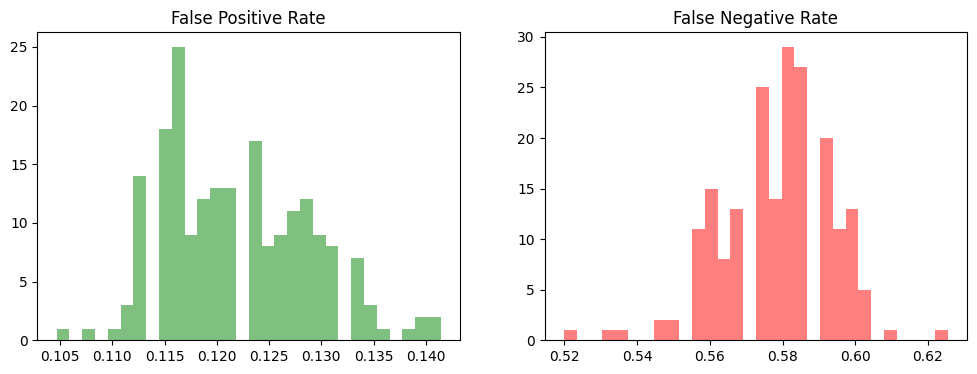

In [62]:
data = data_SRS_ROS

SRS_ROS_FPR = data['FPR']
SRS_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Resampling performance:

Error type: FPR
Mean: 0.12037482319660534
Variance: 4.6494393065499785e-05
Variance of estimate: 2.3247196532749893e-07
Standard error: 0.000482153466572106
95% Confidence Interval:  [ 0.119429802402124 ,  0.12131984399108667 ]
-----------------------------
Error type: FNR
Mean: 0.5873348017621145
Variance: 0.00023930272566426207
Variance of estimate: 1.1965136283213103e-06
Standard error: 0.001093852653843885
95% Confidence Interval:  [ 0.5851908505605805 ,  0.5894787529636485 ]
-----------------------------


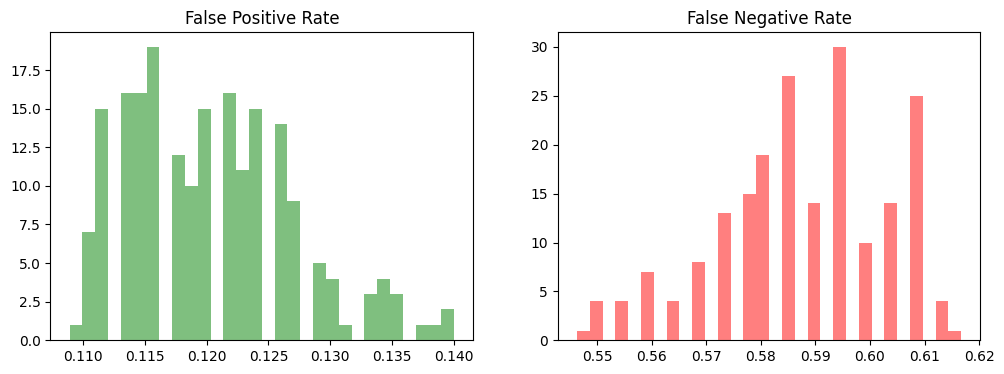

In [63]:
data = data_Sy_ROS

Sy_ROS_FPR = data['FPR']
Sy_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

In [64]:
FPR = pd.DataFrame()

DF = FPR


DF['SRS_RUS'] = SRS_FPR
DF['SRSwR_RUS'] = SRSwR_FPR
DF['Sy_RUS'] = Sy_FPR
DF['Sy_m_RUS'] = Sym_FPR
DF['SRS_ROS'] = SRS_ROS_FPR
DF['Sy_ROS'] = Sy_ROS_FPR
DF['Orig'] = orig_FPR
FPR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.125884,0.113154,0.110325,0.147100,0.120226,0.121641,0.059406
1,0.124470,0.111740,0.115983,0.141443,0.131542,0.120226,0.067893
2,0.125884,0.113154,0.111740,0.127298,0.125884,0.118812,0.069307
3,0.125884,0.111740,0.113154,0.144272,0.121641,0.121641,0.057992
4,0.127298,0.113154,0.115983,0.132956,0.127298,0.123055,0.048091
...,...,...,...,...,...,...,...
195,0.131542,0.113154,0.120226,0.152758,0.115983,0.124470,NaN
196,0.120226,0.114569,0.118812,0.148515,0.120226,0.124470,NaN
197,0.142857,0.113154,0.121641,0.148515,0.115983,0.123055,NaN
198,0.124470,0.111740,0.127298,0.151344,0.113154,0.124470,NaN


<Axes: title={'center': 'FPR'}>

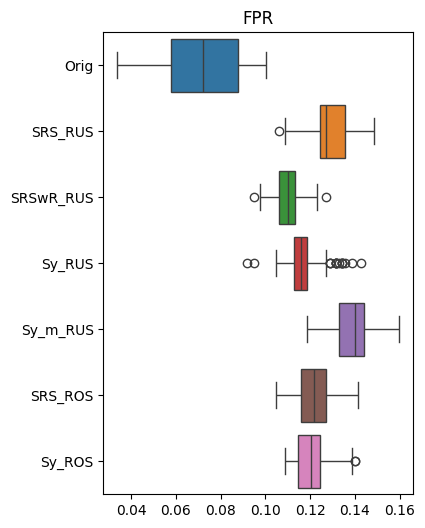

In [65]:
dataset = FPR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FPR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

In [66]:
FNR = pd.DataFrame()

DF = FNR


DF['SRS_RUS'] = SRS_FNR
DF['SRSwR_RUS'] = SRSwR_FNR
DF['Sy_RUS'] = Sy_FNR
DF['Sy_m_RUS'] = Sym_FNR
DF['SRS_ROS'] = SRS_ROS_FNR
DF['Sy_ROS'] = Sy_ROS_FNR
DF['Orig'] = orig_FNR
FNR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.581498,0.594714,0.594714,0.546256,0.585903,0.572687,0.700441
1,0.585903,0.603524,0.581498,0.559471,0.555066,0.581498,0.687225
2,0.585903,0.599119,0.590308,0.590308,0.572687,0.585903,0.687225
3,0.581498,0.607930,0.590308,0.546256,0.585903,0.581498,0.704846
4,0.581498,0.599119,0.581498,0.585903,0.568282,0.572687,0.740088
...,...,...,...,...,...,...,...
195,0.590308,0.616740,0.594714,0.550661,0.590308,0.581498,NaN
196,0.599119,0.594714,0.594714,0.555066,0.581498,0.585903,NaN
197,0.572687,0.607930,0.594714,0.559471,0.585903,0.585903,NaN
198,0.590308,0.616740,0.590308,0.537445,0.603524,0.577093,NaN


<Axes: title={'center': 'FNR'}>

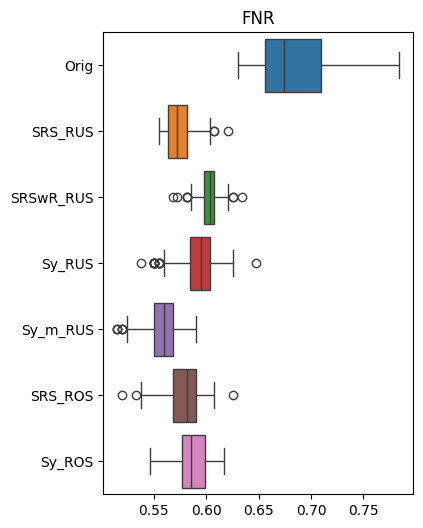

In [67]:
dataset = FNR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FNR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

## "CIFAR-10" Data:

In [68]:
path_to_data = 'https://raw.githubusercontent.com/AndreiAf02/Resolving_Data_Imbalance/main/Transfer_Learning/CIFAR10/'

In [69]:
data_orig = pd.read_csv(path_to_data+ "CIFAR_Fine_Tuning_Imbalanced.csv", sep=",", header=0)
data_SRS = pd.read_csv(path_to_data+ "CIFAR_SRS_Fine_Tuning.csv", sep=",", header=0)
data_SRSwR = pd.read_csv(path_to_data+ "CIFAR_SRSwR_Fine_Tuning.csv", sep=",", header=0)
data_Sy = pd.read_csv(path_to_data+ "CIFAR_Sy_Fine_Tuning.csv", sep=",", header=0)
data_Sym = pd.read_csv(path_to_data+ "CIFAR_Sy_multi_Fine_Tuning.csv", sep=",", header=0)
data_SRS_ROS = pd.read_csv(path_to_data+ "CIFAR_SRS_ROS_Fine_Tuning.csv", sep=",", header=0)
data_Sy_ROS = pd.read_csv(path_to_data+ "CIFAR_Sy_ROS_Fine_Tuning.csv", sep=",", header=0)

data_Sy_ROS

,Unnamed: 0,FPR,FNR
0,0,0.360,0.516
1,1,0.358,0.516
2,2,0.380,0.510
3,3,0.354,0.530
4,4,0.365,0.506
...,...,...,...
95,45,0.377,0.510
96,46,0.402,0.492
97,47,0.388,0.510
98,48,0.368,0.526


Original (imbalanced) data performance:

Error type: FPR
Mean: 0.08285999999999999
Variance: 0.00025575551020408165
Variance of estimate: 5.115110204081633e-06
Standard error: 0.002261660939239486
95% Confidence Interval:  [ 0.0784271445590906 ,  0.08729285544090938 ]
-----------------------------
Error type: FNR
Mean: 0.76304
Variance: 0.0012805289795918375
Variance of estimate: 2.561057959183675e-05
Standard error: 0.005060689635991991
95% Confidence Interval:  [ 0.7531210483134557 ,  0.7729589516865444 ]
-----------------------------


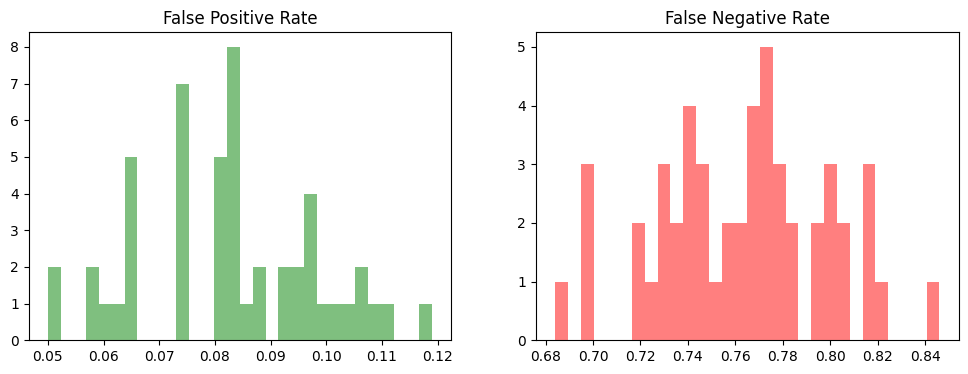

In [70]:
data = data_orig

orig_FPR = data['FPR']
orig_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

**Random Undersampling:**

SRS Random Undersampling performance:

Error type: FPR
Mean: 0.32516
Variance: 0.0007018731313131318
Variance of estimate: 7.018731313131318e-06
Standard error: 0.0026492888315793953
95% Confidence Interval:  [ 0.31996739389010437 ,  0.33035260610989564 ]
-----------------------------
Error type: FNR
Mean: 0.5025200000000001
Variance: 0.0005073632323232329
Variance of estimate: 5.073632323232329e-06
Standard error: 0.002252472491115558
95% Confidence Interval:  [ 0.49810515391741356 ,  0.5069348460825865 ]
-----------------------------


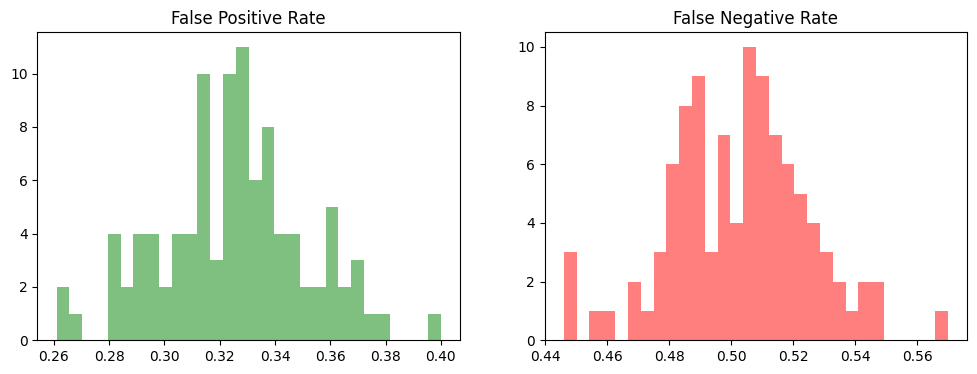

In [71]:
data = data_SRS

SRS_FPR = data['FPR']
SRS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

SRSwR undersampling performance:

Error type: FPR
Mean: 0.36408
Variance: 0.0007174884848484848
Variance of estimate: 7.174884848484847e-06
Standard error: 0.0026785975525421596
95% Confidence Interval:  [ 0.3588299487970174 ,  0.3693300512029826 ]
-----------------------------
Error type: FNR
Mean: 0.50562
Variance: 0.000419046060606061
Variance of estimate: 4.19046060606061e-06
Standard error: 0.0020470614563467826
95% Confidence Interval:  [ 0.5016077595455603 ,  0.5096322404544397 ]
-----------------------------


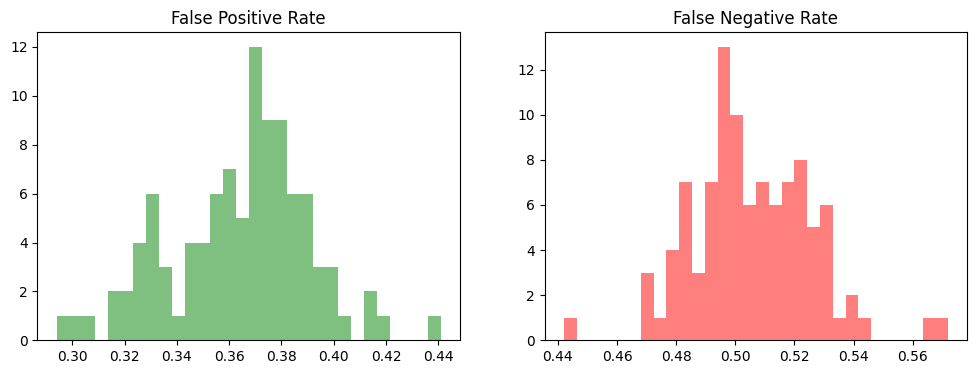

In [72]:
data = data_SRSwR

SRSwR_FPR = data['FPR']
SRSwR_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Undersampling performance:

Error type: FPR
Mean: 0.32159000000000004
Variance: 0.000548385757575758
Variance of estimate: 5.4838575757575796e-06
Standard error: 0.002341763774542082
95% Confidence Interval:  [ 0.31700014300189755 ,  0.32617985699810254 ]
-----------------------------
Error type: FNR
Mean: 0.5182800000000001
Variance: 0.0005527288888888893
Variance of estimate: 5.527288888888893e-06
Standard error: 0.002351018691735328
95% Confidence Interval:  [ 0.5136720033641988 ,  0.5228879966358013 ]
-----------------------------


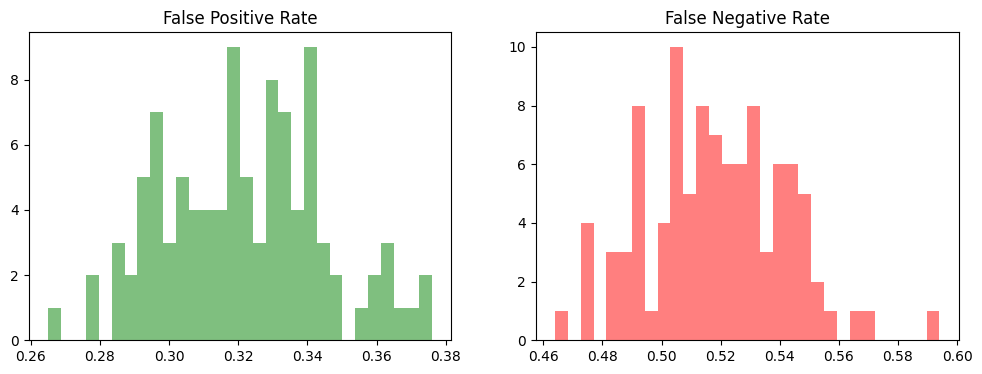

In [73]:
data = data_Sy

Sy_FPR = data['FPR']
Sy_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Multiple Systematic undersampling performance:

Error type: FPR
Mean: 0.35247
Variance: 0.0005110798989898989
Variance of estimate: 5.110798989898989e-06
Standard error: 0.002260707630344753
95% Confidence Interval:  [ 0.3480390130445243 ,  0.35690098695547573 ]
-----------------------------
Error type: FNR
Mean: 0.51154
Variance: 0.0006252812121212126
Variance of estimate: 6.252812121212127e-06
Standard error: 0.002500562360992448
95% Confidence Interval:  [ 0.5066388977724547 ,  0.5164411022275452 ]
-----------------------------


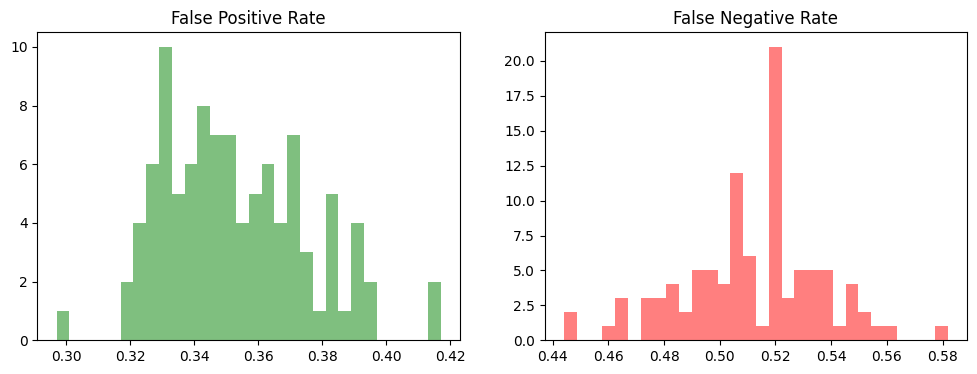

In [74]:
data = data_Sym

Sym_FPR = data['FPR']
Sym_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

**Random Oversampling:**

SRS Oversampling performance:

Error type: FPR
Mean: 0.3810300000000001
Variance: 0.000500049595959596
Variance of estimate: 5.000495959595961e-06
Standard error: 0.0022361788746868977
95% Confidence Interval:  [ 0.37664708940561376 ,  0.3854129105943864 ]
-----------------------------
Error type: FNR
Mean: 0.49252
Variance: 0.0006138682828282833
Variance of estimate: 6.138682828282833e-06
Standard error: 0.0024776365407950442
95% Confidence Interval:  [ 0.48766383238004174 ,  0.4973761676199583 ]
-----------------------------


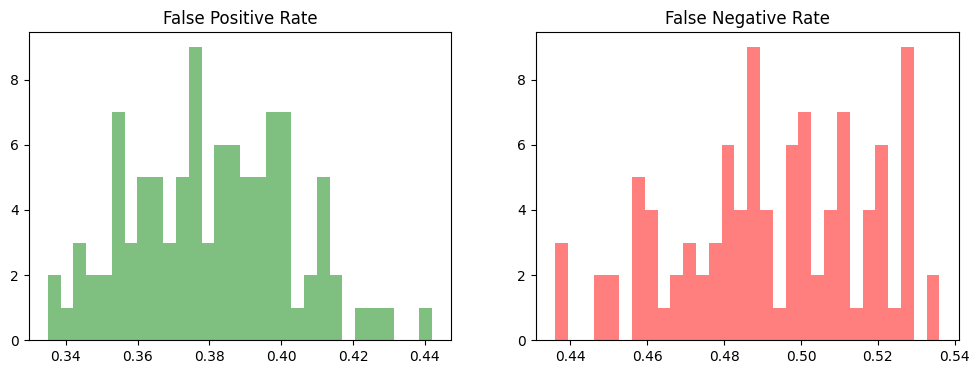

In [75]:
data = data_SRS_ROS

SRS_ROS_FPR = data['FPR']
SRS_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

Systematic Resampling performance:

Error type: FPR
Mean: 0.37902
Variance: 0.0005094137373737378
Variance of estimate: 5.094137373737378e-06
Standard error: 0.0022570195776149965
95% Confidence Interval:  [ 0.37459624162787464 ,  0.3834437583721254 ]
-----------------------------
Error type: FNR
Mean: 0.5111000000000001
Variance: 0.001158818181818182
Variance of estimate: 1.1588181818181821e-05
Standard error: 0.0034041418622292787
95% Confidence Interval:  [ 0.5044278819500307 ,  0.5177721180499695 ]
-----------------------------


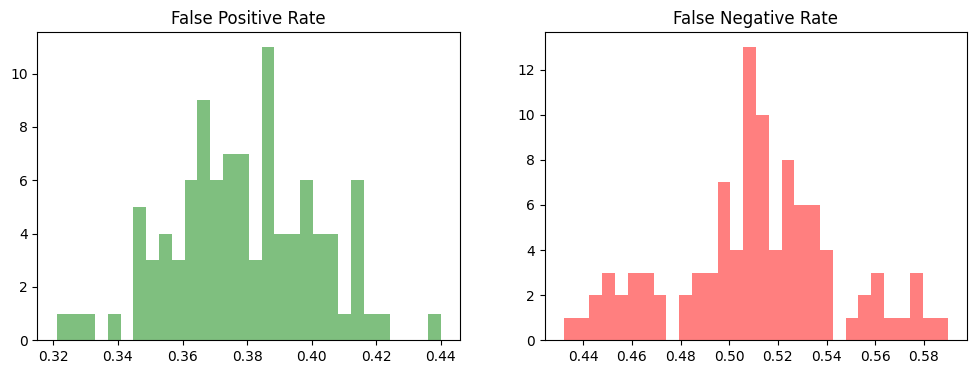

In [76]:
data = data_Sy_ROS

Sy_ROS_FPR = data['FPR']
Sy_ROS_FNR = data['FNR']

fig = plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(data['FPR'], color='g', bins=30, label='FPR', alpha=0.5)
plt.title('False Positive Rate')

plt.subplot(1, 2, 2)
plt.hist(data['FNR'], color='r', bins=30, label='FNR', alpha=0.5)
plt.title('False Negative Rate')
# plt.show()

perf_metrics(data, 'FPR')
perf_metrics(data, 'FNR')

In [77]:
FPR = pd.DataFrame()

DF = FPR


DF['SRS_RUS'] = SRS_FPR
DF['SRSwR_RUS'] = SRSwR_FPR
DF['Sy_RUS'] = Sy_FPR
DF['Sy_m_RUS'] = Sym_FPR
DF['SRS_ROS'] = SRS_ROS_FPR
DF['Sy_ROS'] = Sy_ROS_FPR
DF['Orig'] = orig_FPR
FPR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.324,0.379,0.321,0.337,0.383,0.360,0.108
1,0.314,0.379,0.330,0.335,0.390,0.358,0.096
2,0.292,0.362,0.284,0.341,0.395,0.380,0.100
3,0.360,0.355,0.330,0.349,0.396,0.354,0.083
4,0.345,0.360,0.359,0.336,0.402,0.365,0.098
...,...,...,...,...,...,...,...
95,0.283,0.365,0.298,0.332,0.376,0.377,NaN
96,0.285,0.329,0.315,0.321,0.381,0.402,NaN
97,0.301,0.351,0.335,0.416,0.362,0.388,NaN
98,0.281,0.363,0.297,0.381,0.389,0.368,NaN


<Axes: title={'center': 'FPR'}>

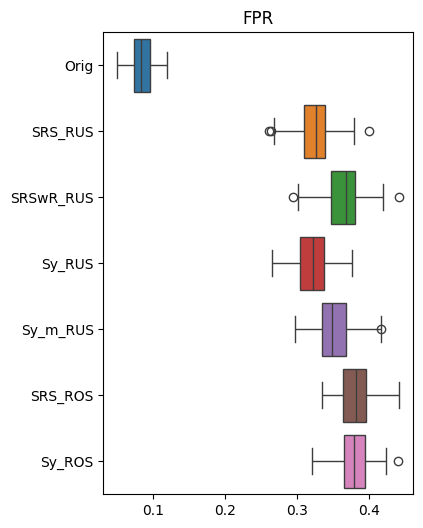

In [78]:
dataset = FPR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FPR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')

In [79]:
FNR = pd.DataFrame()

DF = FNR


DF['SRS_RUS'] = SRS_FNR
DF['SRSwR_RUS'] = SRSwR_FNR
DF['Sy_RUS'] = Sy_FNR
DF['Sy_m_RUS'] = Sym_FNR
DF['SRS_ROS'] = SRS_ROS_FNR
DF['Sy_ROS'] = Sy_ROS_FNR
DF['Orig'] = orig_FNR
FNR

,SRS_RUS,SRSwR_RUS,Sy_RUS,Sy_m_RUS,SRS_ROS,Sy_ROS,Orig
0,0.506,0.502,0.550,0.522,0.520,0.516,0.700
1,0.504,0.504,0.540,0.518,0.502,0.516,0.726
2,0.522,0.516,0.594,0.522,0.502,0.510,0.732
3,0.488,0.526,0.540,0.508,0.502,0.530,0.766
4,0.484,0.516,0.512,0.522,0.484,0.506,0.718
...,...,...,...,...,...,...,...
95,0.520,0.500,0.538,0.546,0.502,0.510,NaN
96,0.512,0.536,0.506,0.562,0.486,0.492,NaN
97,0.488,0.524,0.494,0.464,0.516,0.510,NaN
98,0.522,0.512,0.528,0.490,0.478,0.526,NaN


<Axes: title={'center': 'FNR'}>

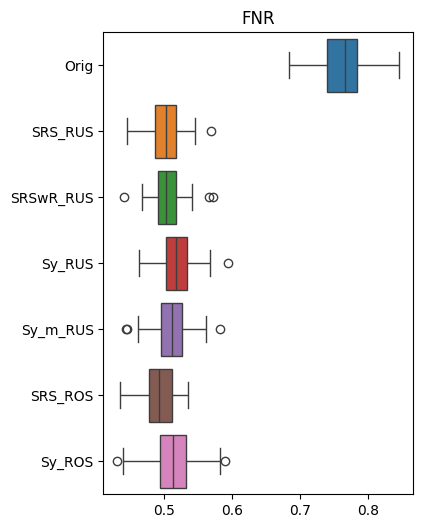

In [80]:
dataset = FNR

plt.figure(figsize=(4,6)) #, dpi=600)
plt.title('FNR')
sns.boxplot([dataset['Orig'], dataset['SRS_RUS'], dataset['SRSwR_RUS'],
             dataset['Sy_RUS'], dataset['Sy_m_RUS'], dataset['SRS_ROS'], dataset['Sy_ROS']], orient='h')